In [1]:
import gei_nj
gei_nj.__version__

import os
from glob import glob
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt
from kneed import KneeLocator
from gei_nj import plot_snv_pca_by_group, build_and_plot_nj

In [2]:
## Functions for calculation of GEI-NJ tree accuracy

import numpy as np
import pandas as pd


def fmt_p_up(x: float) -> str:
    return f"{x:.0e}"


def extract_tree_from_return(obj):
    if hasattr(obj, "get_terminals"):
        return obj

    if isinstance(obj, dict):
        for key in ["tree", "nj_tree", "phylo_tree", "Tree"]:
            if key in obj and hasattr(obj[key], "get_terminals"):
                return obj[key]

    if isinstance(obj, (tuple, list)):
        for item in obj:
            tree = extract_tree_from_return(item)
            if tree is not None:
                return tree

    return None


def lineage_n_parts(label):
    return len(str(label).split("-"))


def is_ancestor_or_descendant(label_a, label_b):
    parts_a = str(label_a).split("-")
    parts_b = str(label_b).split("-")
    min_len = min(len(parts_a), len(parts_b))
    return parts_a[:min_len] == parts_b[:min_len]


def get_compatible_lineage_labels(target_group, observed_groups):
    return {
        group
        for group in observed_groups
        if is_ancestor_or_descendant(target_group, group)
    }


def evaluate_topology_lineage_Q(
    tree_return,
    adata,
    group_key="group",
    target_n_parts=3,
    outgroup_names=("Synthetic_Non_SNV_Outgroup", "Synthetic non-SNV outgroup"),
):
    tree = extract_tree_from_return(tree_return)

    if tree is None:
        raise ValueError(
            "Could not extract a Bio.Phylo-like tree from build_and_plot_nj() output. "
            "Please run build_and_plot_nj(..., return_tree_info=True)."
        )

    outgroup_names = set(outgroup_names)
    leaf_to_group = adata.obs[group_key].astype(str).to_dict()

    terminals = [
        terminal
        for terminal in tree.get_terminals()
        if str(terminal.name) not in outgroup_names
    ]

    terminal_names = [str(terminal.name) for terminal in terminals]

    observed_groups = [
        leaf_to_group[name]
        for name in terminal_names
        if name in leaf_to_group
    ]

    target_groups = sorted(
        {
            group
            for group in observed_groups
            if lineage_n_parts(group) == target_n_parts
        }
    )

    all_clades = list(tree.find_clades(order="preorder"))

    records = []

    for target_group in target_groups:
        n_target_total = sum(group == target_group for group in observed_groups)

        compatible_labels = get_compatible_lineage_labels(
            target_group,
            observed_groups,
        )

        best_target_count = 0
        best_clade_size = 0
        best_compatible_labels = set()
        best_wrong_labels = set()
        best_has_context = False

        for clade in all_clades:
            clade_terminals = [
                terminal
                for terminal in clade.get_terminals()
                if str(terminal.name) not in outgroup_names
            ]

            clade_labels = [
                leaf_to_group[str(terminal.name)]
                for terminal in clade_terminals
                if str(terminal.name) in leaf_to_group
            ]

            if len(clade_labels) == 0:
                continue

            target_count = sum(label == target_group for label in clade_labels)

            if target_count == 0:
                continue

            wrong_labels = {
                label
                for label in clade_labels
                if label not in compatible_labels
            }

            has_context = any(
                label in compatible_labels and label != target_group
                for label in clade_labels
            )

            if len(wrong_labels) == 0:
                if n_target_total == 1:
                    if has_context and target_count >= best_target_count:
                        best_target_count = target_count
                        best_clade_size = len(clade_labels)
                        best_compatible_labels = set(clade_labels)
                        best_wrong_labels = wrong_labels
                        best_has_context = has_context
                else:
                    if target_count > best_target_count:
                        best_target_count = target_count
                        best_clade_size = len(clade_labels)
                        best_compatible_labels = set(clade_labels)
                        best_wrong_labels = wrong_labels
                        best_has_context = has_context

        if n_target_total == 1:
            q_k = 1.0 if best_target_count == 1 and best_has_context else 0.0
        else:
            q_k = (best_target_count - 1) / (n_target_total - 1)
            q_k = max(0.0, q_k)

        records.append(
            {
                "target_group": target_group,
                "n_target_cells": int(n_target_total),
                "best_clean_clade_target_cells": int(best_target_count),
                "best_clean_clade_size": int(best_clade_size),
                "best_clean_clade_fraction": best_target_count / n_target_total,
                "topology_lineage_Q_k": q_k,
                "compatible_labels": ";".join(sorted(compatible_labels)),
                "labels_in_best_clean_clade": ";".join(sorted(best_compatible_labels)),
                "wrong_labels_in_best_clean_clade": ";".join(sorted(best_wrong_labels)),
                "singleton_target": n_target_total == 1,
                "singleton_has_compatible_context": bool(best_has_context),
            }
        )

    result_df = pd.DataFrame(records)

    if result_df.shape[0] == 0:
        summary = {
            "n_target_groups": 0,
            "n_target_cells": 0,
            "n_singleton_target_groups": 0,
            "topology_lineage_Q_percent": np.nan,
            "target_n_parts": target_n_parts,
        }
        return result_df, summary

    topology_lineage_Q = float(result_df["topology_lineage_Q_k"].mean())

    summary = {
        "n_target_groups": int(result_df.shape[0]),
        "n_target_cells": int(result_df["n_target_cells"].sum()),
        "n_singleton_target_groups": int(result_df["singleton_target"].sum()),
        "topology_lineage_Q_percent": topology_lineage_Q * 100,
        "target_n_parts": target_n_parts,
    }

    return result_df, summary

In [3]:
## Settings for plots

gen_colors = {
    0: "red", 1: "#481F70", 2: "#443A83", 3: "#3B528B", 4: "#31688E",
    5: "#287C8E", 6: "#21908C", 7: "#20A486", 8: "#35B779",
    9: "#5DC863", 10: "#8FD744", 11: "#C7E020", 12: "#FDE725"
}

p_ups = [1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
n_groups = [2, 3]  # lineage levels for accuracy Q; n_group=2 means labels such as 0-0-0
max_cells = [20, 50]

group_colors2 = {'0': "#31688E", '0-0': "#35B779", '0-1': "#7550a6", '0-0-0': "#ecf20f",
                 '0-0-1': "#3bed82", '0-1-2': "#f294df", '0-1-3': "#ed7e98"}

group_colors3 = {'0': "#31688E", '0-0': "#35B779", '0-1': "#7550a6", '0-0-0': "#ecf20f",
                 '0-0-1': "#3bed82", '0-1-2': "#f294df", '0-1-3': "#ed7e98",
                 '0-0-0-0': "#e8e15b", '0-0-0-1': "#c6cc8b", '0-0-1-2': "#36f2ce", '0-0-1-3': "#3ec5db",
                 '0-1-2-4': "#b195ef", '0-1-2-5': "#db77d6", '0-1-3-6': "#ed7f66", '0-1-3-7': "#f4bebe"}

group_colors_by_ngroup = {2: group_colors2, 3: group_colors3}

infile_template = (
    "./h5ad_simu_filtered/"
    "max{max_cells}_cells_per_generation/"
    "diploid_12_generations_1cell_1e+08mutations_{p_up}_"
    "max{max_cells}cells_per_generation_nonzeroSNV.h5ad")

outdir_root = "Simulation_setting1_with_GEINJ"


####################################################################################################
Start analyses for max_cells = 20
Output folder: Simulation_setting1_with_GEINJ/max20_cells_per_generation

Processing p_up = 1e-05
Processing max_cells = 20
Input file: ./h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad
adata.shape: (191, 463361)
Number of available PCs: 30


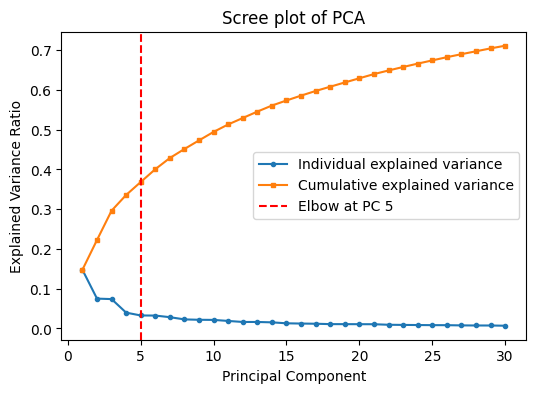

Automatically detected elbow PC number: 5
Saved elbow plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p01.PC_elbow_mutations_1e-05_maxcells_20_plot.pdf


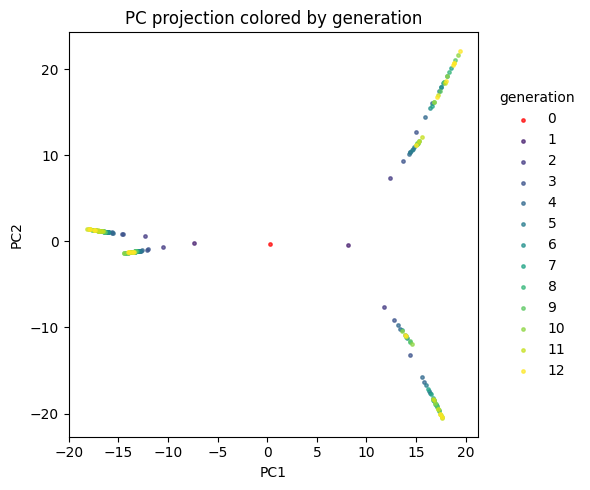

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_generation_mutations_1e-05_maxcells_20.pdf


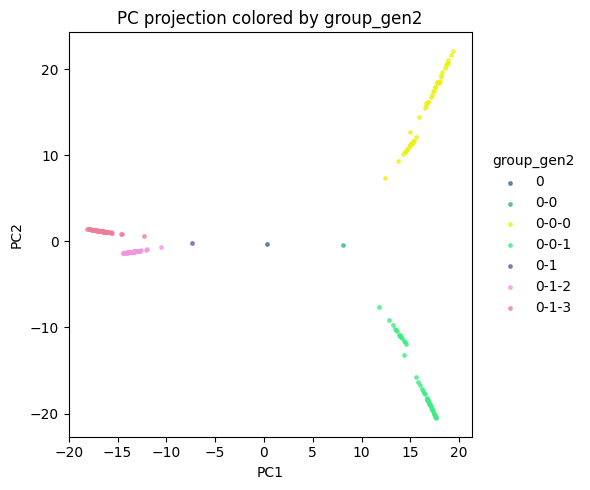

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-05_maxcells_20.pdf


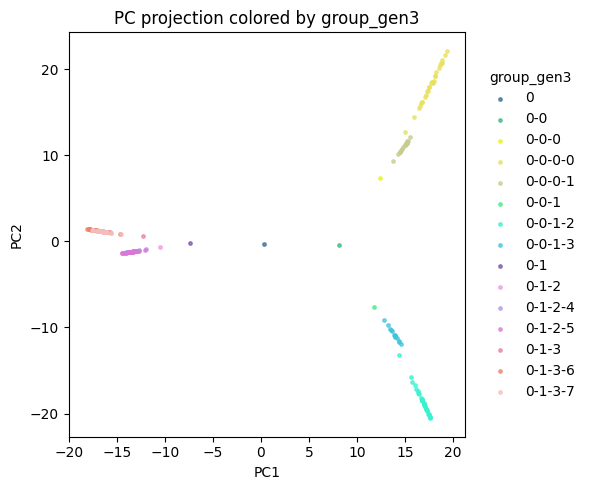

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-05_maxcells_20.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-05, max_cells = 20, n_group = 2, K mode = PC2, K_tree = 2


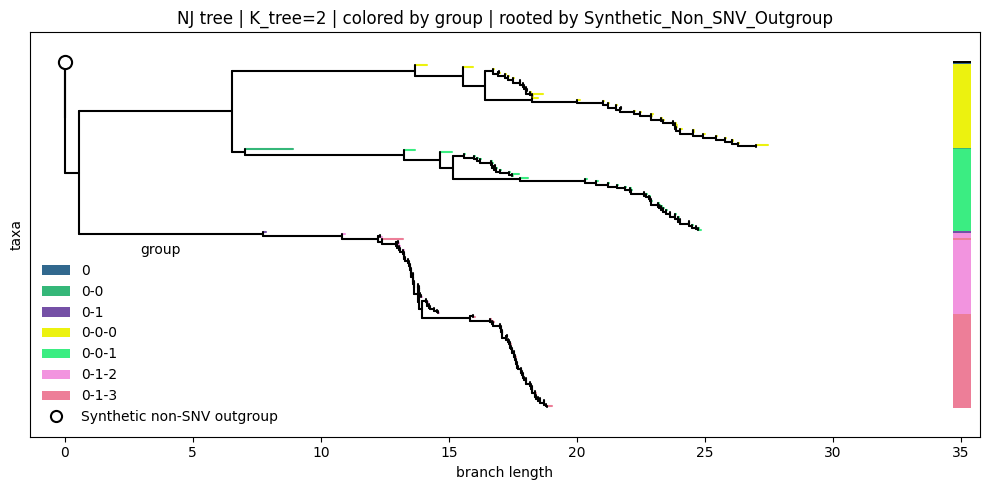

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-05_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-05_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 79.17039355992844, 'target_n_parts': 3, 'p_up': '1e-05', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 5, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 463361, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-05_maxcells_20

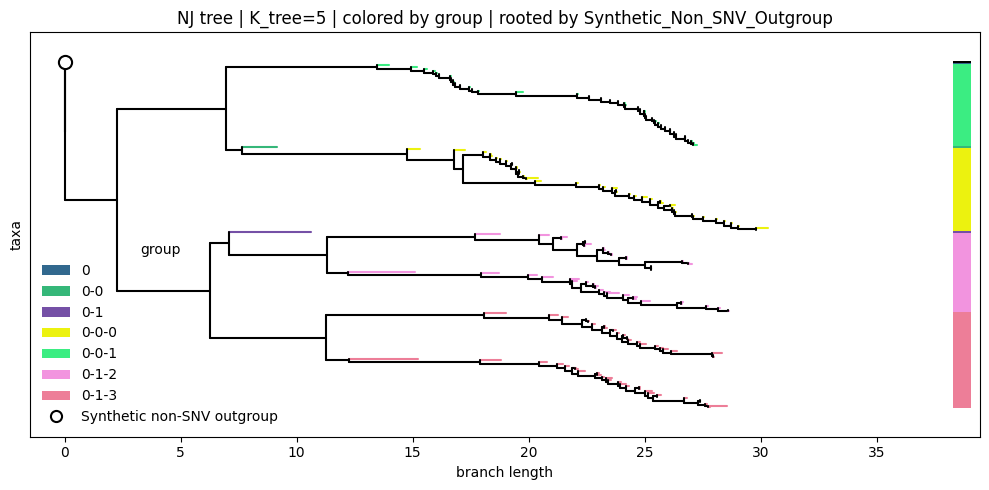

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K5_mutations_1e-05_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K5_mutations_1e-05_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-05', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 5, 'elbow_PC': 5, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 463361, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K5_mutations_1e-05_max

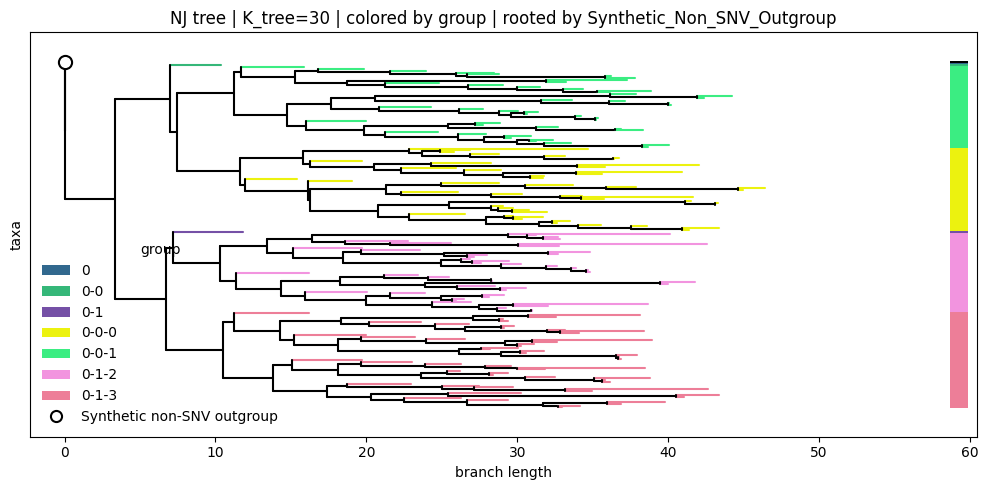

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-05_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-05_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-05', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 5, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 463361, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-05_maxcells_20.pdf

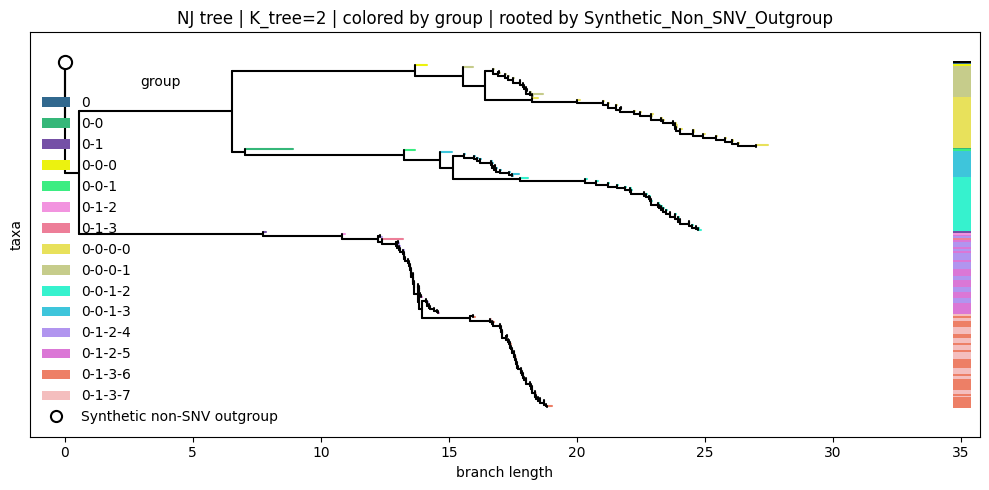

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-05_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-05_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 55.40808150183151, 'target_n_parts': 4, 'p_up': '1e-05', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 5, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 463361, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-05_maxcells_2

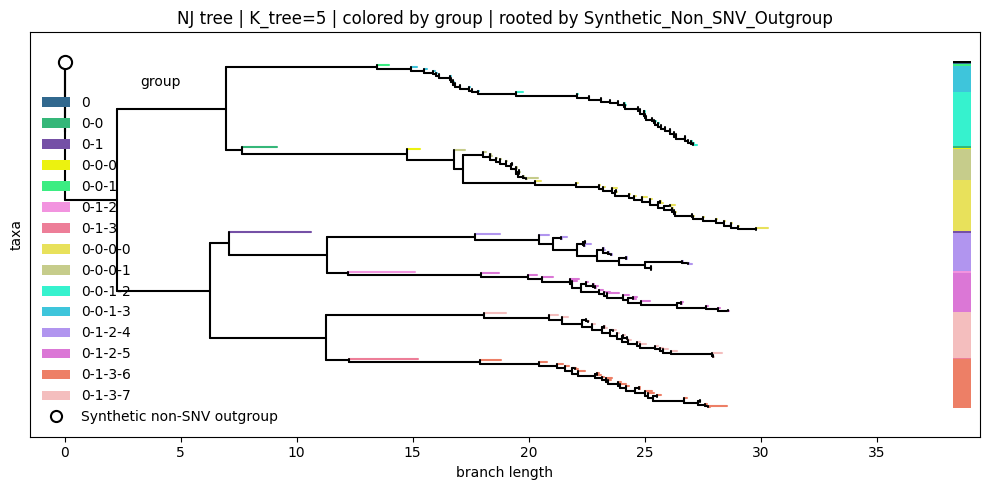

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K5_mutations_1e-05_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K5_mutations_1e-05_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 86.71875, 'target_n_parts': 4, 'p_up': '1e-05', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 5, 'elbow_PC': 5, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 463361, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K5_mutations_1e-05

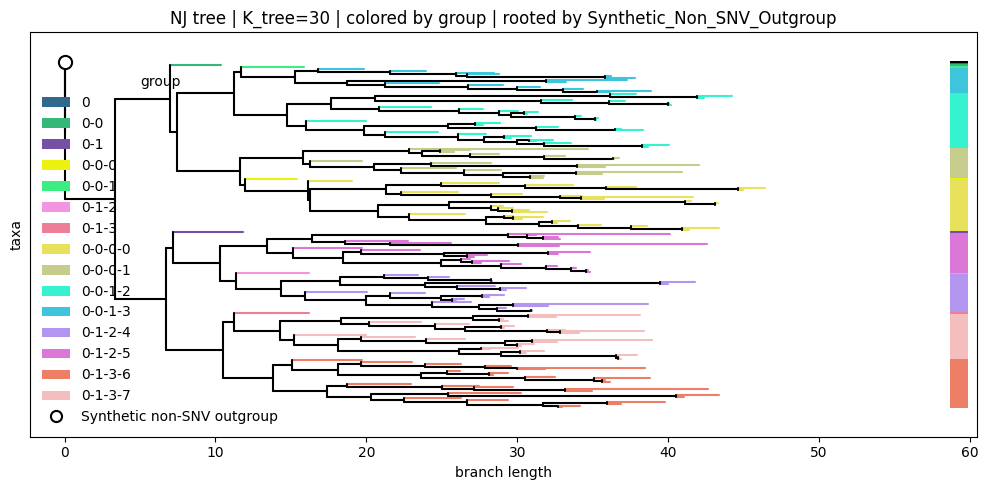

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-05_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-05_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-05', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 5, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 463361, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-05_maxcells_20.pd

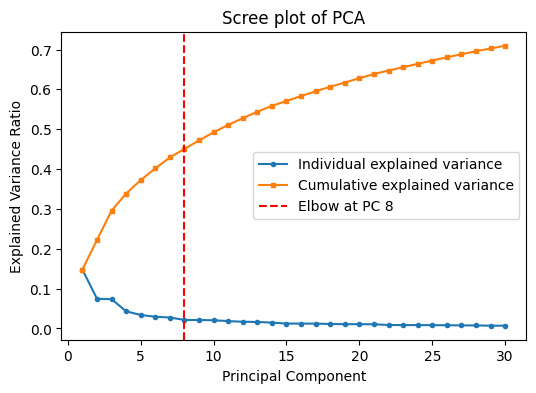

Automatically detected elbow PC number: 8
Saved elbow plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p01.PC_elbow_mutations_1e-06_maxcells_20_plot.pdf


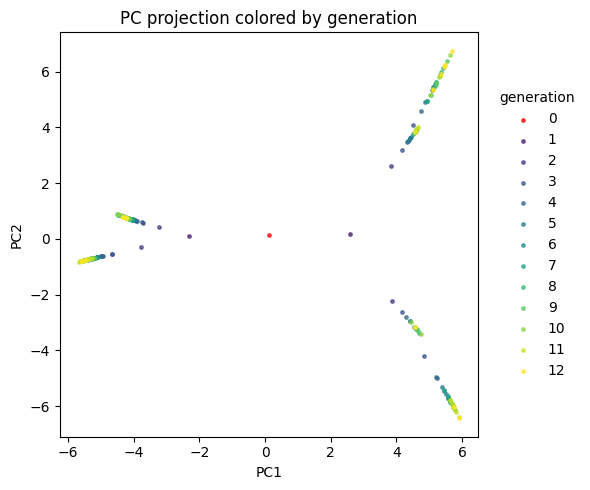

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_generation_mutations_1e-06_maxcells_20.pdf


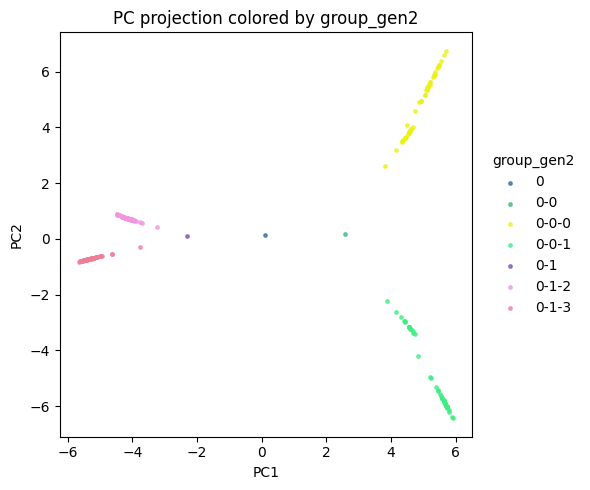

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-06_maxcells_20.pdf


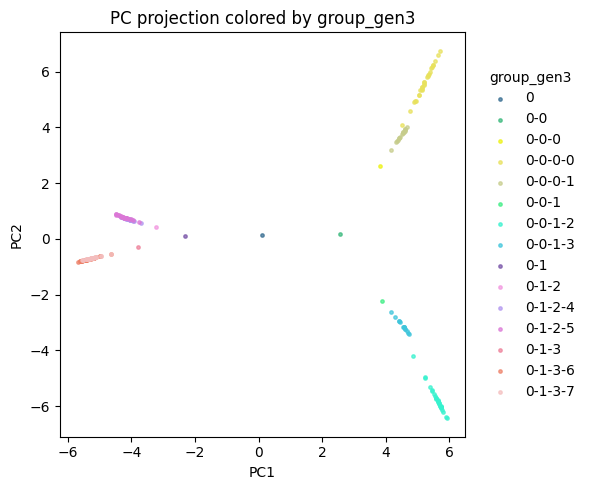

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-06_maxcells_20.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-06, max_cells = 20, n_group = 2, K mode = PC2, K_tree = 2


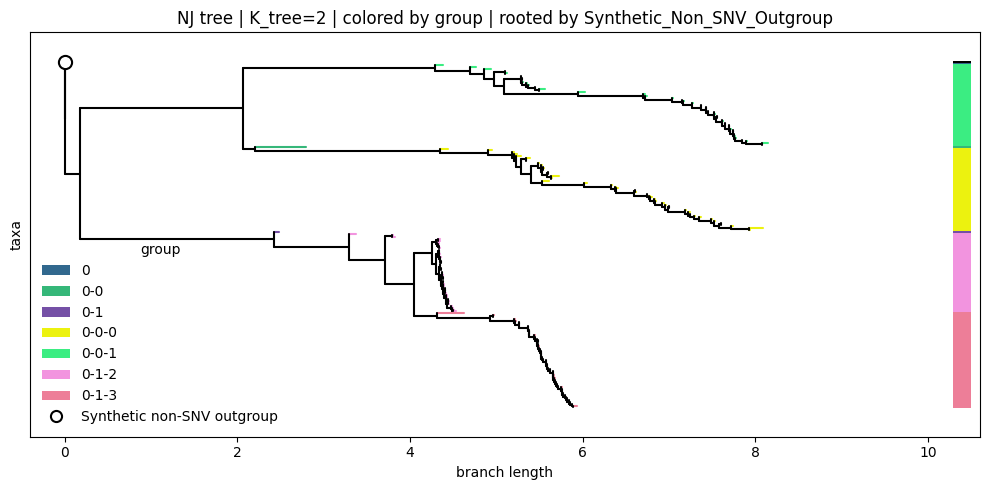

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-06_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-06_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 98.25581395348837, 'target_n_parts': 3, 'p_up': '1e-06', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 46059, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-06_maxcells_20.

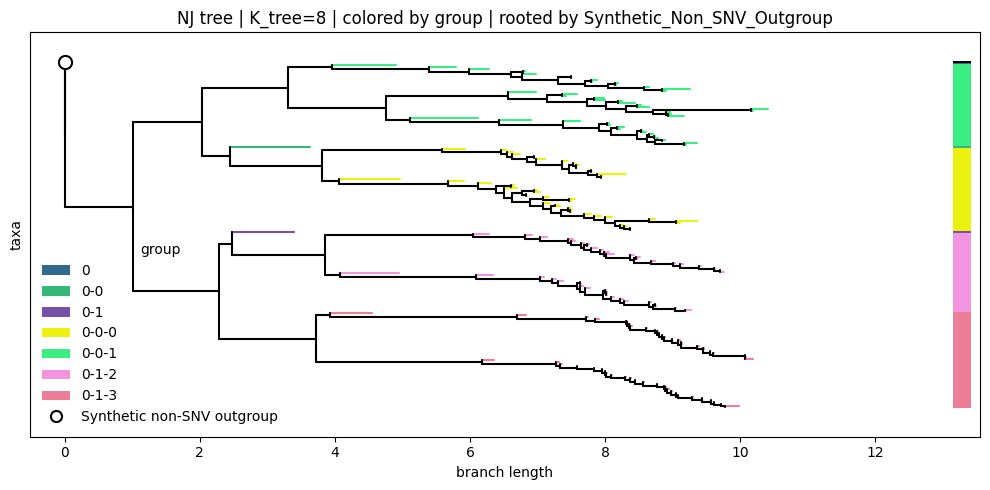

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K8_mutations_1e-06_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K8_mutations_1e-06_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-06', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 8, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 46059, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K8_mutations_1e-06_maxc

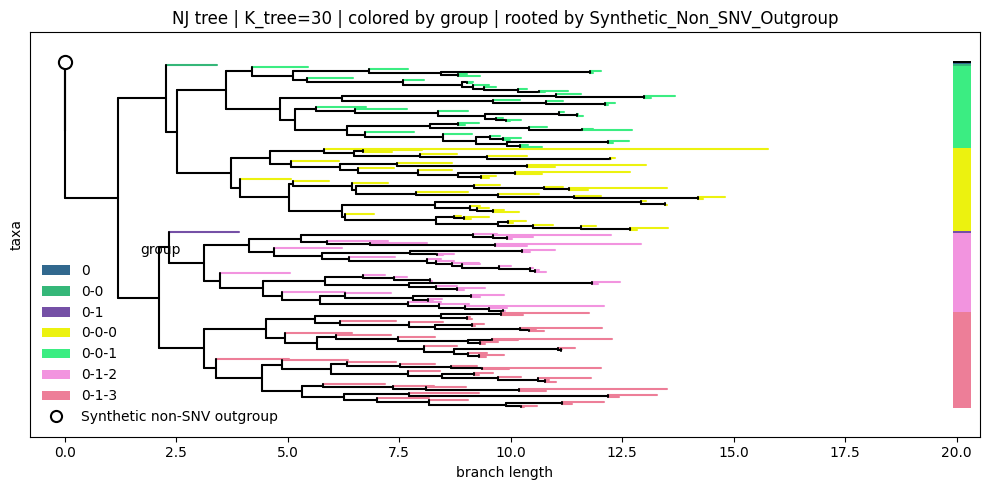

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-06_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-06_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-06', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 46059, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-06_maxcells_20.pdf'

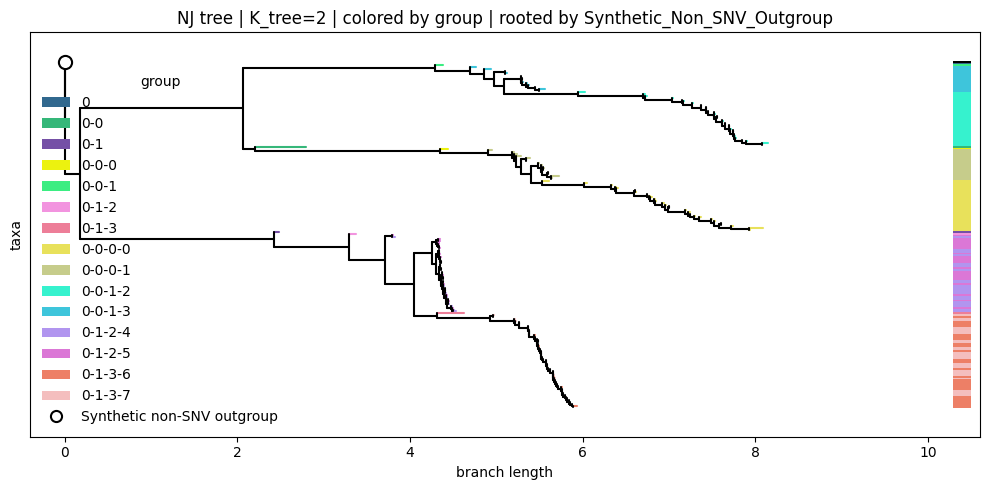

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-06_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-06_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 47.98019688644688, 'target_n_parts': 4, 'p_up': '1e-06', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 46059, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-06_maxcells_20

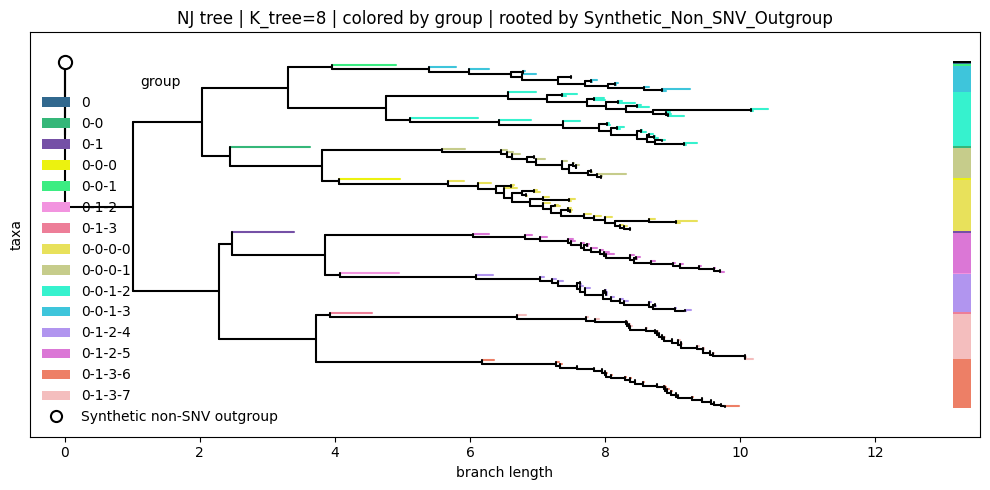

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K8_mutations_1e-06_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K8_mutations_1e-06_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-06', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 8, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 46059, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K8_mutations_1e-06_max

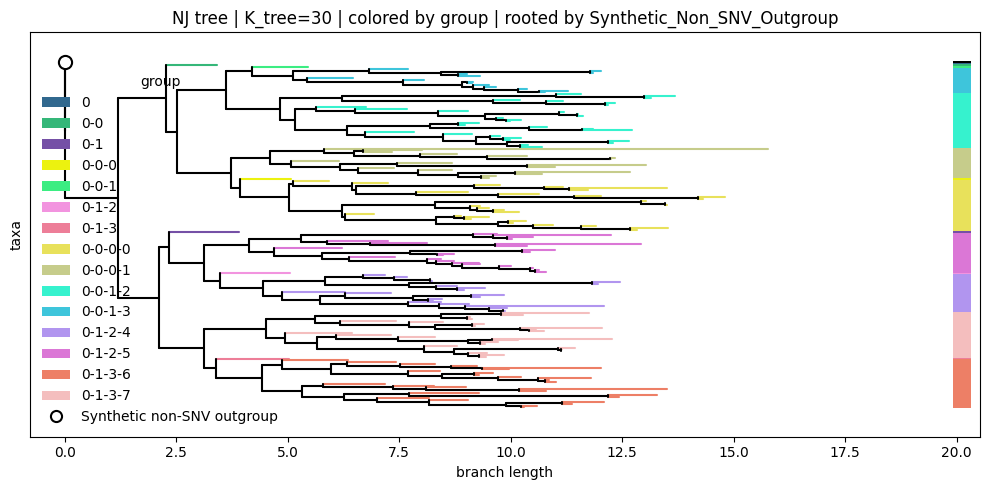

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-06_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-06_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-06', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 46059, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-06_maxcells_20.pdf

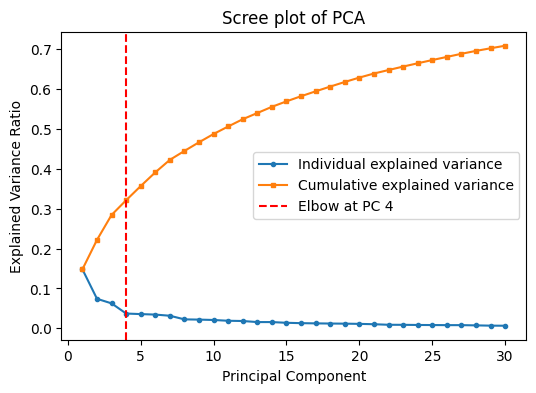

Automatically detected elbow PC number: 4
Saved elbow plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p01.PC_elbow_mutations_1e-07_maxcells_20_plot.pdf


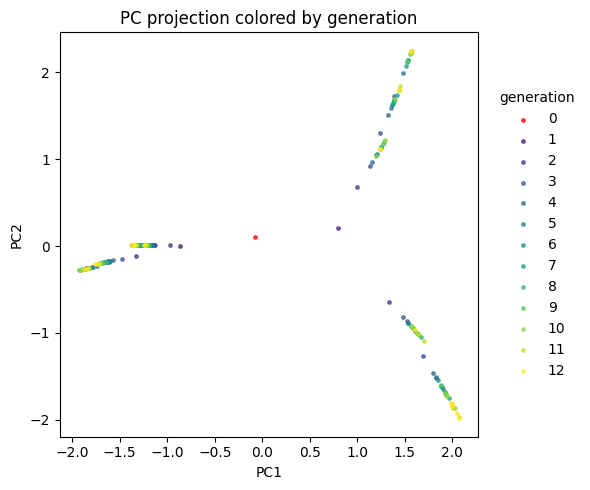

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_generation_mutations_1e-07_maxcells_20.pdf


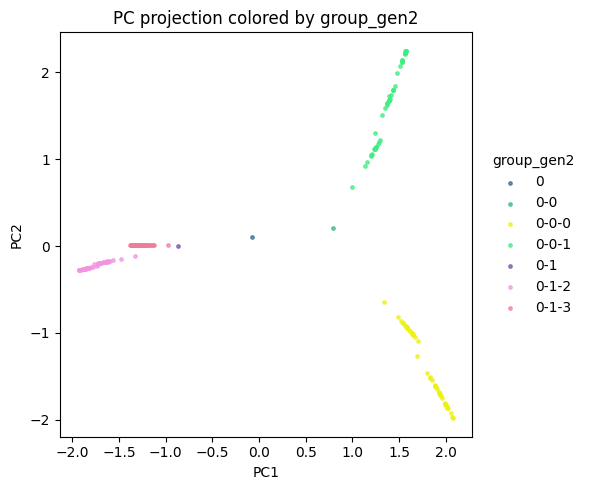

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-07_maxcells_20.pdf


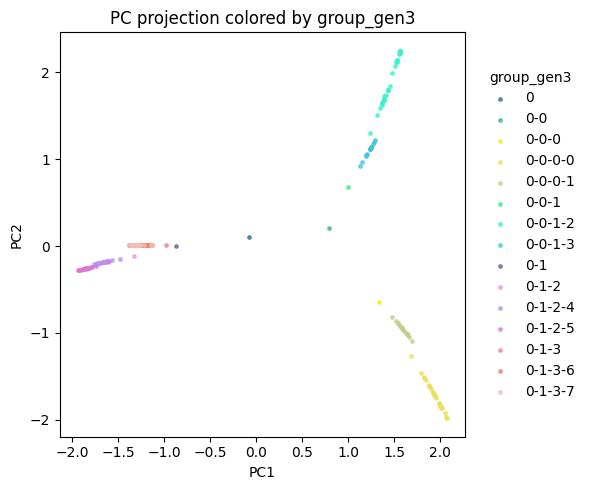

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-07_maxcells_20.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-07, max_cells = 20, n_group = 2, K mode = PC2, K_tree = 2


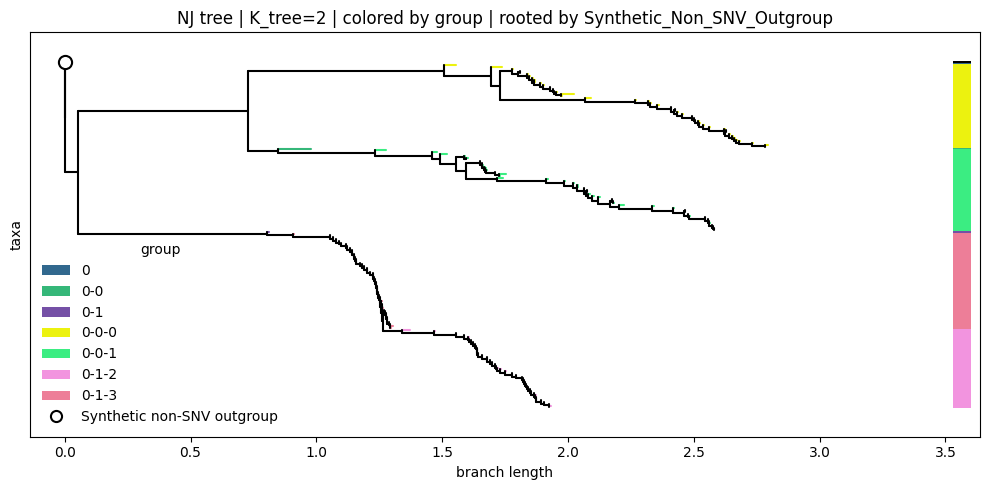

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-07_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-07_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 79.8076923076923, 'target_n_parts': 3, 'p_up': '1e-07', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 4666, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-07_maxcells_20.pd

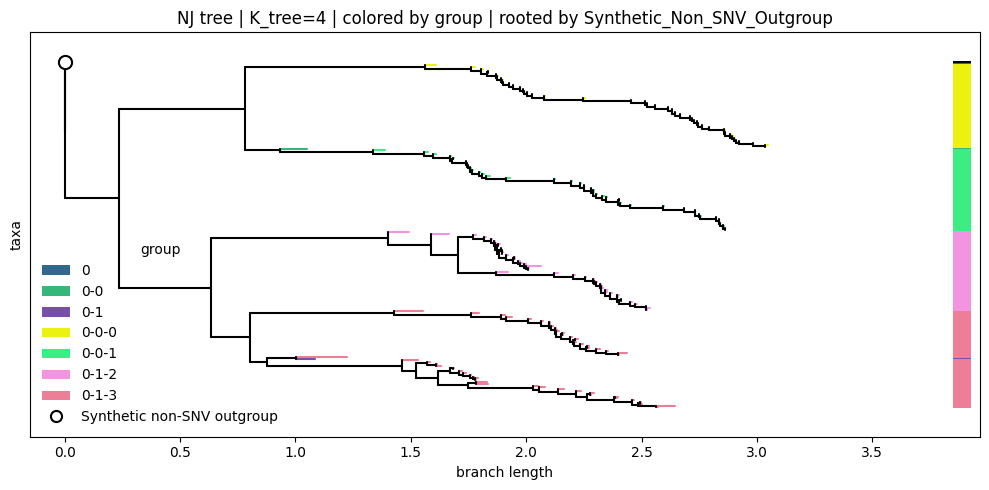

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-07_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K4_mutations_1e-07_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-07', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 4666, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-07_maxce

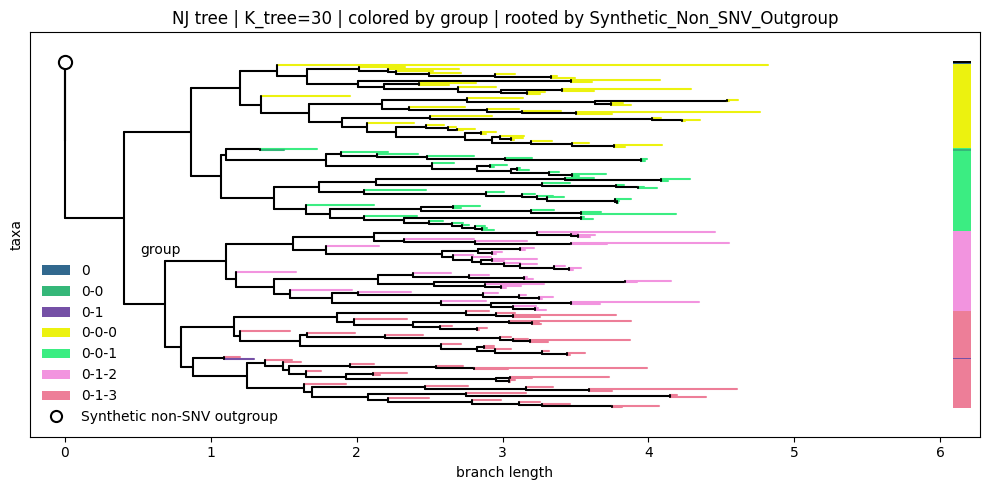

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-07_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-07_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-07', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 4666, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-07_maxcells_20.pdf',

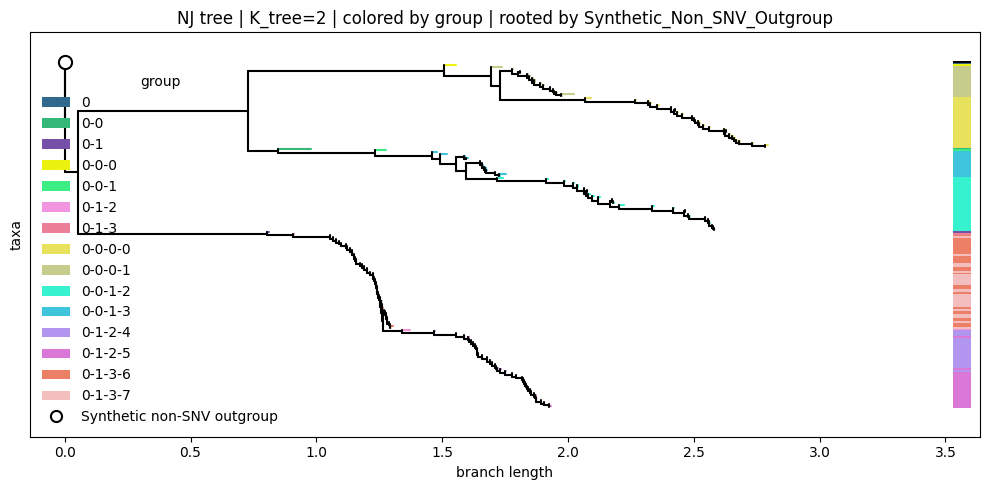

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-07_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-07_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 56.24141483516484, 'target_n_parts': 4, 'p_up': '1e-07', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 4666, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-07_maxcells_20.

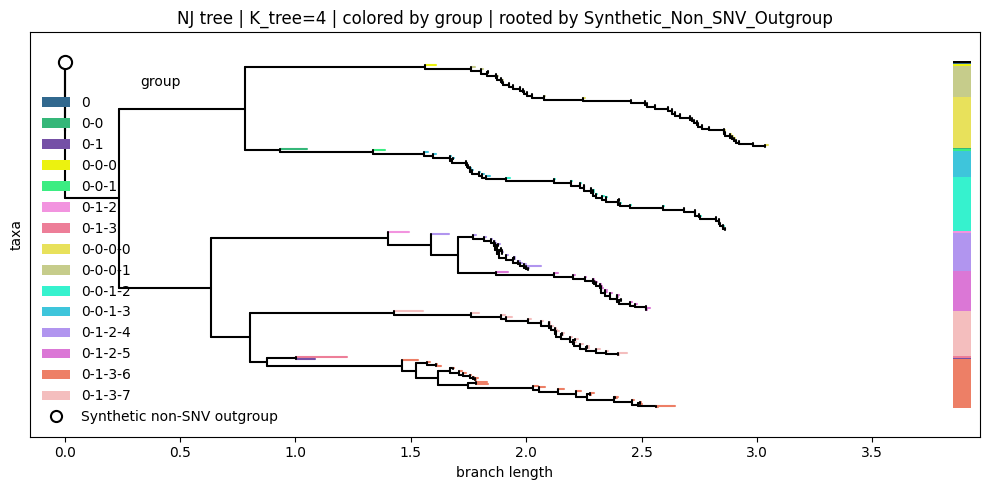

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutations_1e-07_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K4_mutations_1e-07_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 76.11778846153847, 'target_n_parts': 4, 'p_up': '1e-07', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 4666, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutation

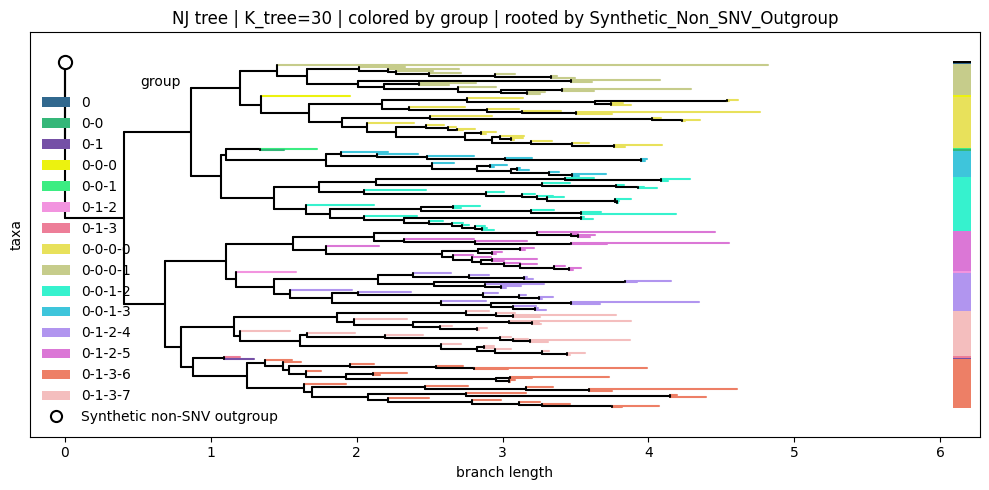

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-07_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-07_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-07', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 4666, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-07_maxcells_20.pdf'

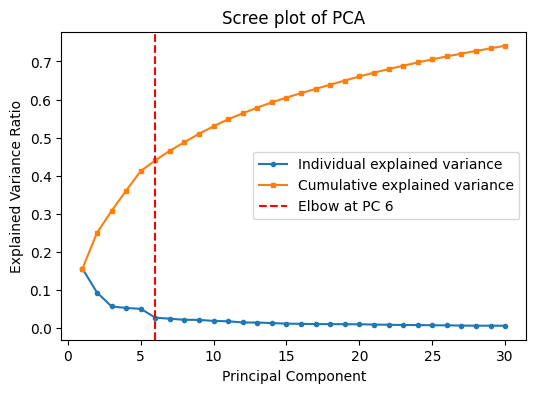

Automatically detected elbow PC number: 6
Saved elbow plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p01.PC_elbow_mutations_1e-08_maxcells_20_plot.pdf


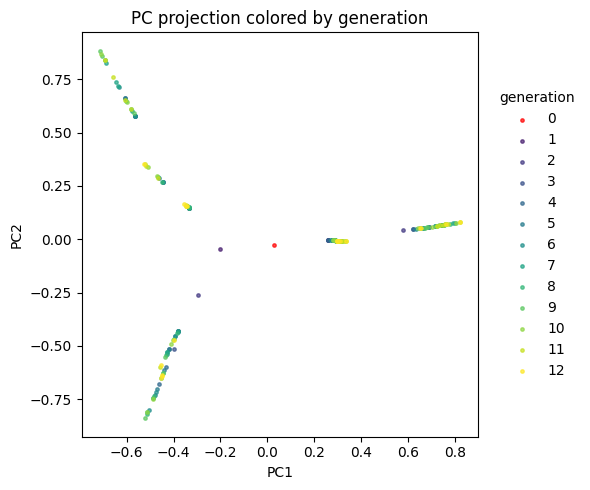

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_generation_mutations_1e-08_maxcells_20.pdf


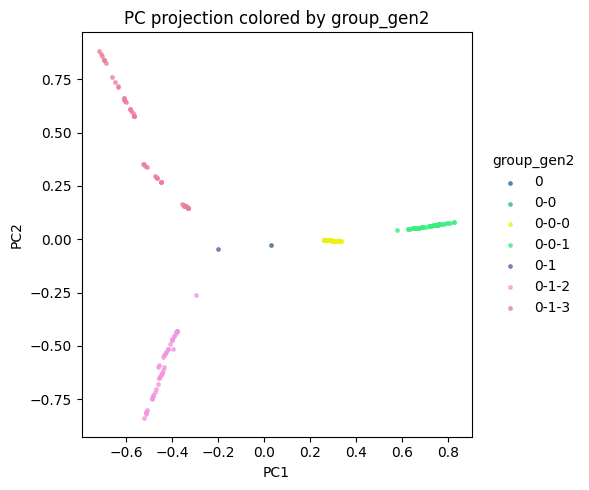

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-08_maxcells_20.pdf


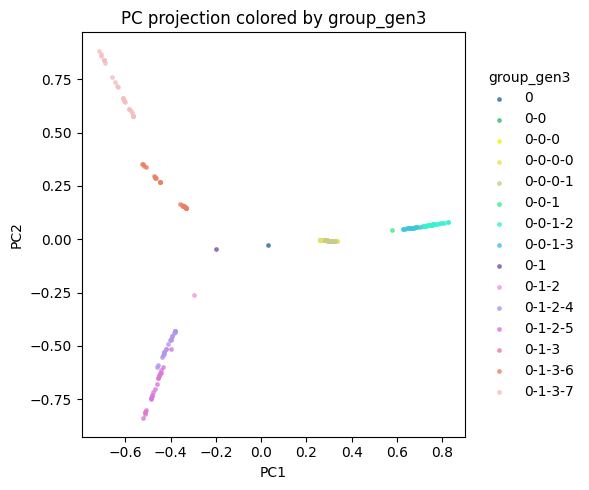

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-08_maxcells_20.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-08, max_cells = 20, n_group = 2, K mode = PC2, K_tree = 2


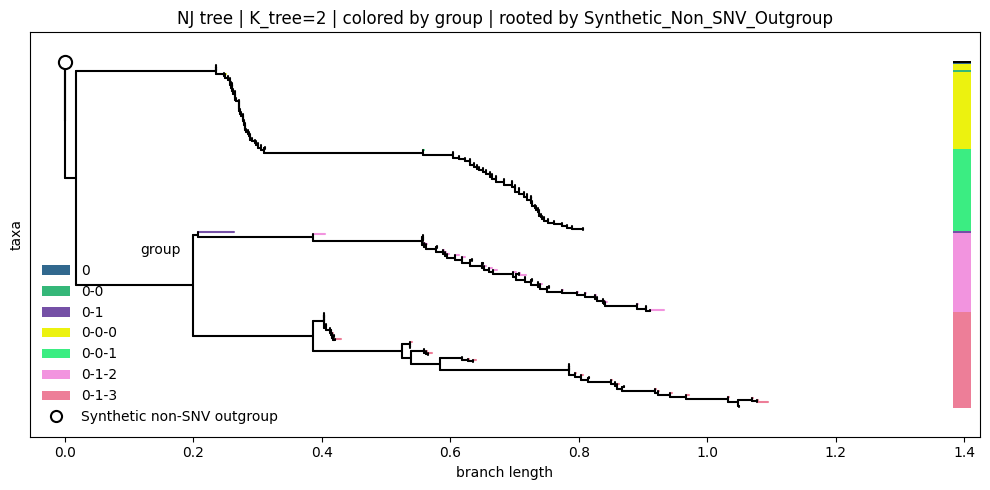

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-08_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-08_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 76.11111111111111, 'target_n_parts': 3, 'p_up': '1e-08', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 478, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-08_maxcells_20.pd

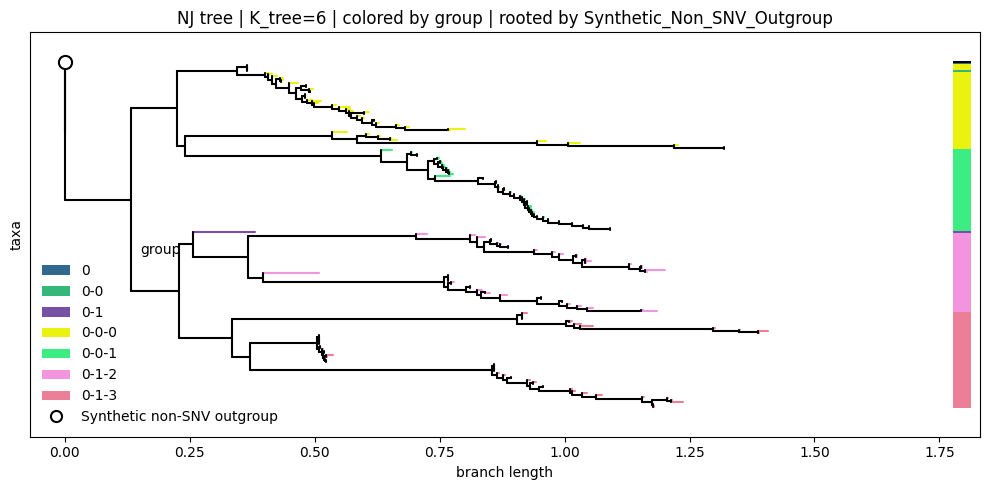

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K6_mutations_1e-08_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K6_mutations_1e-08_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 94.44444444444444, 'target_n_parts': 3, 'p_up': '1e-08', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 6, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 478, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K6_mutations_

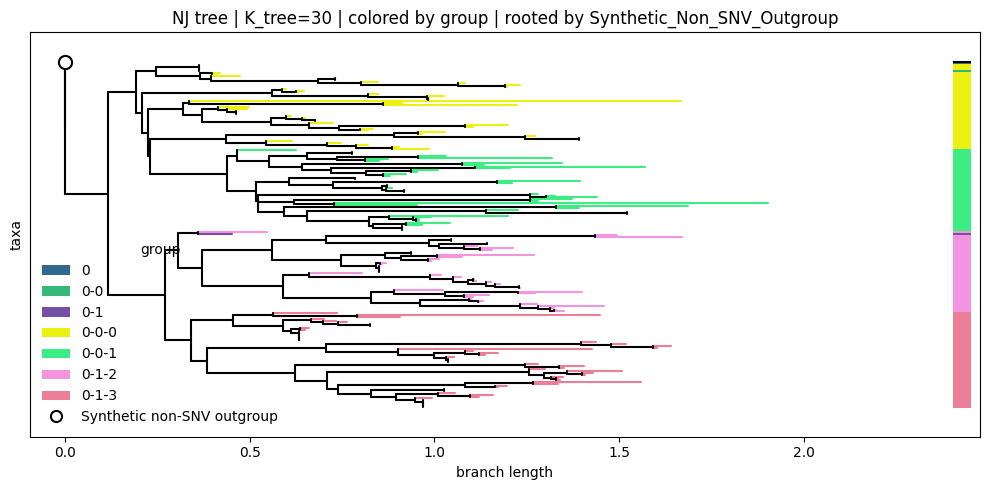

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-08_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-08_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 83.88888888888889, 'target_n_parts': 3, 'p_up': '1e-08', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 478, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-08_maxcel

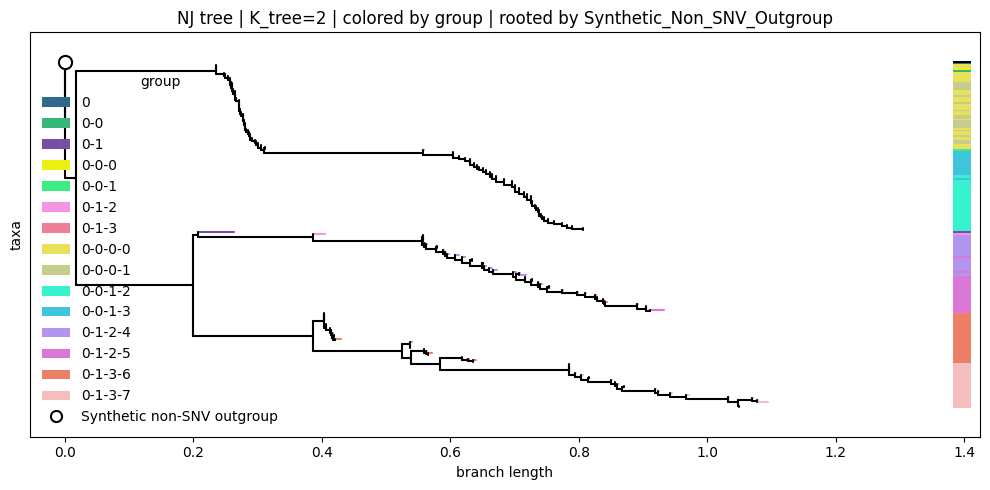

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-08_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-08_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 47.04022549927722, 'target_n_parts': 4, 'p_up': '1e-08', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 478, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-08_maxcells_20.p

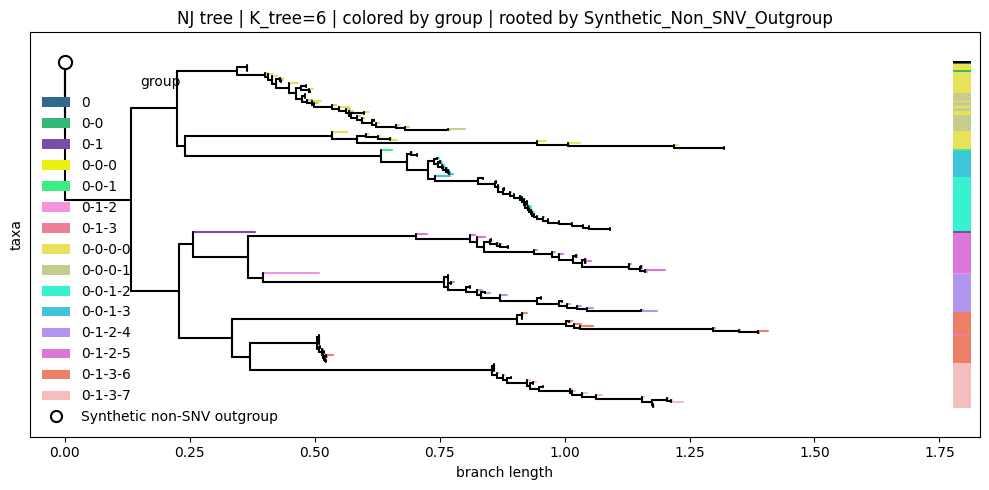

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K6_mutations_1e-08_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K6_mutations_1e-08_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 75.80128205128204, 'target_n_parts': 4, 'p_up': '1e-08', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 6, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 478, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K6_mutations

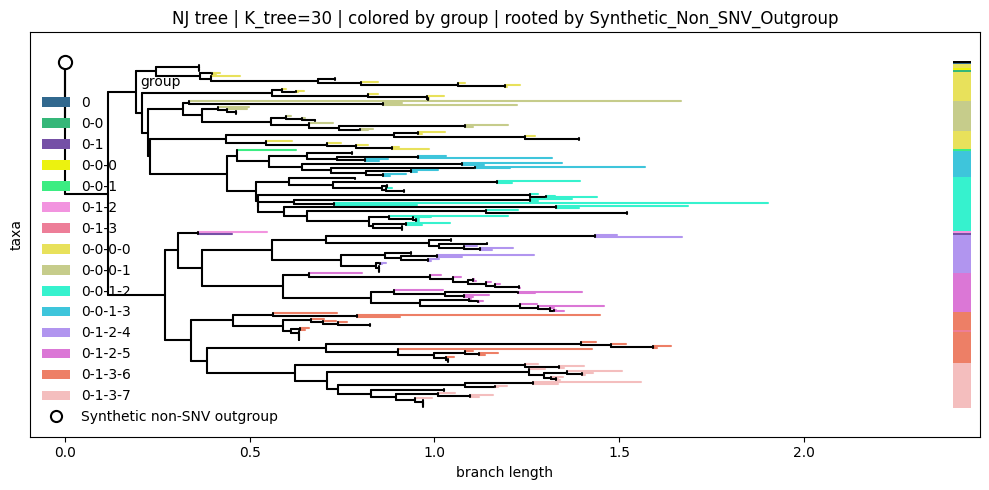

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-08_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-08_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 86.36039886039886, 'target_n_parts': 4, 'p_up': '1e-08', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 478, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-08_maxce

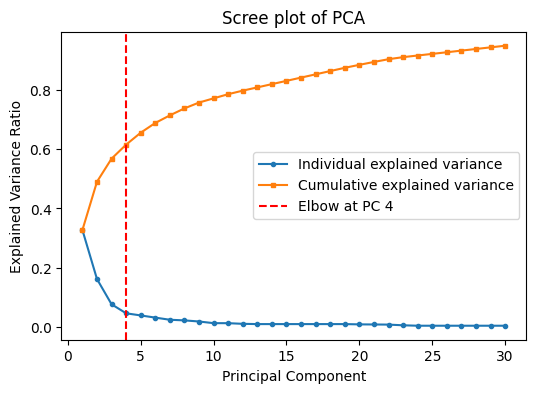

Automatically detected elbow PC number: 4
Saved elbow plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p01.PC_elbow_mutations_1e-09_maxcells_20_plot.pdf


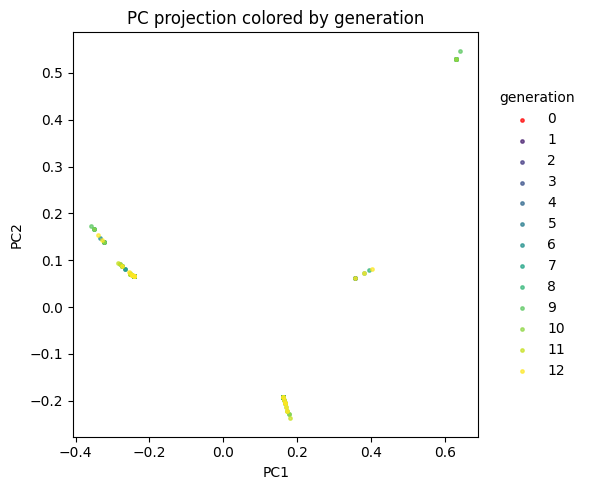

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_generation_mutations_1e-09_maxcells_20.pdf


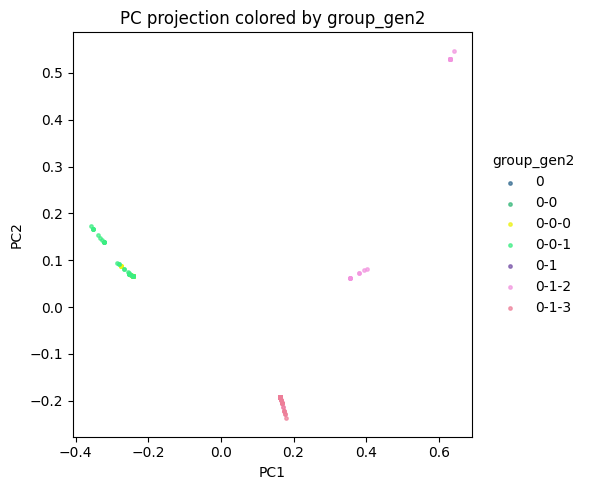

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-09_maxcells_20.pdf


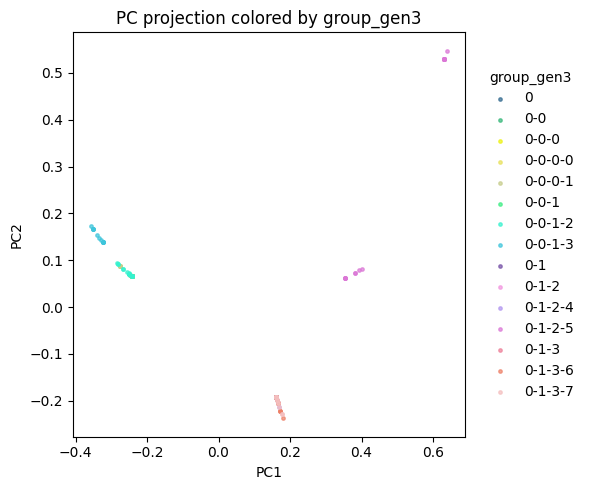

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-09_maxcells_20.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-09, max_cells = 20, n_group = 2, K mode = PC2, K_tree = 2


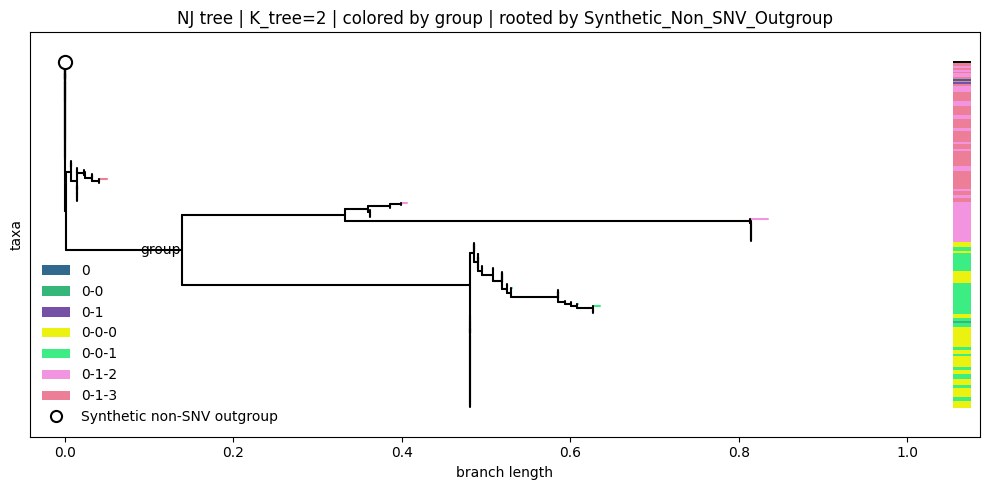

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-09_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-09_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 27.518160134439203, 'target_n_parts': 3, 'p_up': '1e-09', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 48, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-09_maxcells_20.pd

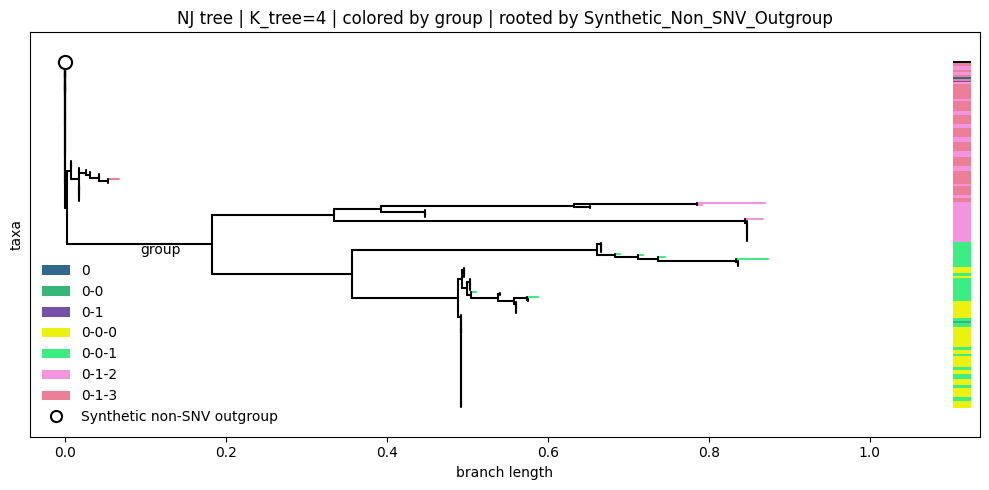

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-09_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K4_mutations_1e-09_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 25.81361467989375, 'target_n_parts': 3, 'p_up': '1e-09', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 48, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1

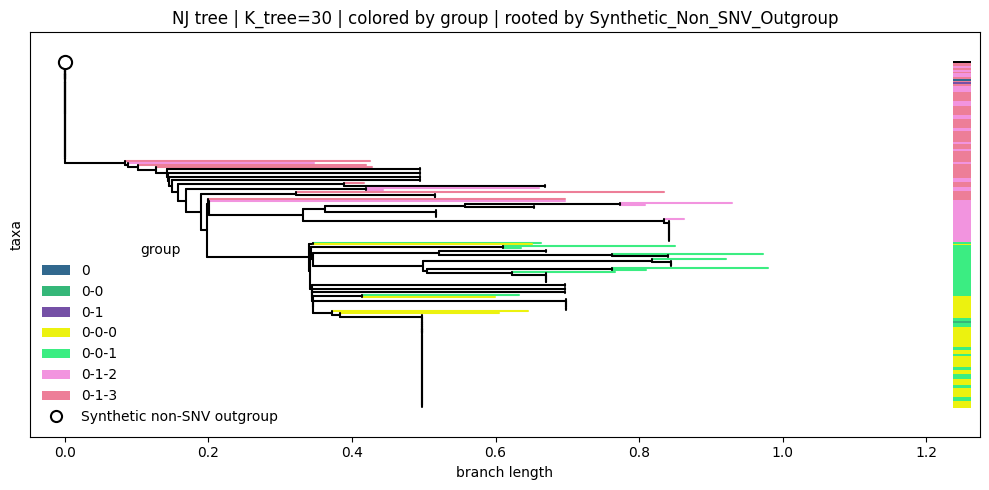

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-09_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-09_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 188, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 29.410744294465225, 'target_n_parts': 3, 'p_up': '1e-09', 'max_cells': 20, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 48, 'n_obs_for_tree': 191, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-09_maxcel

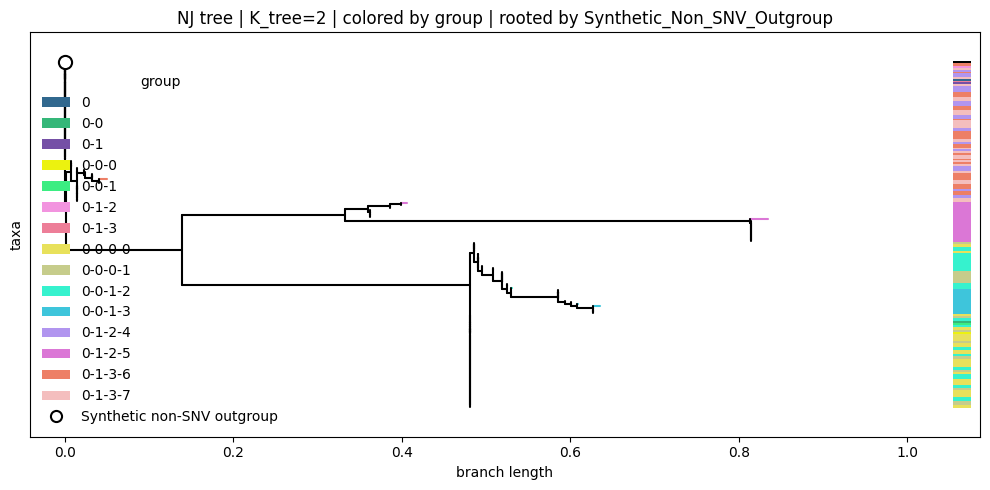

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-09_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-09_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 34.41300717162786, 'target_n_parts': 4, 'p_up': '1e-09', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 48, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-09_maxcells_20.pd

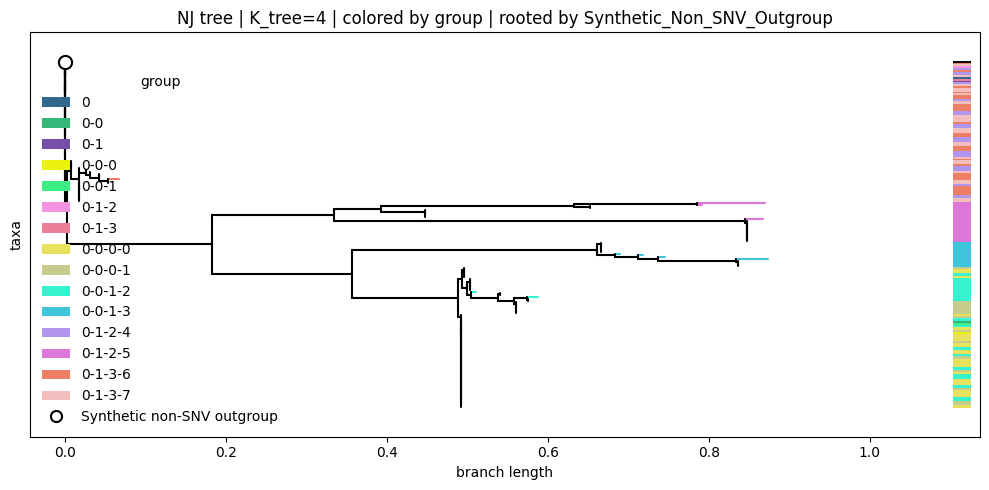

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutations_1e-09_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K4_mutations_1e-09_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 34.84404165438648, 'target_n_parts': 4, 'p_up': '1e-09', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 48, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutations_

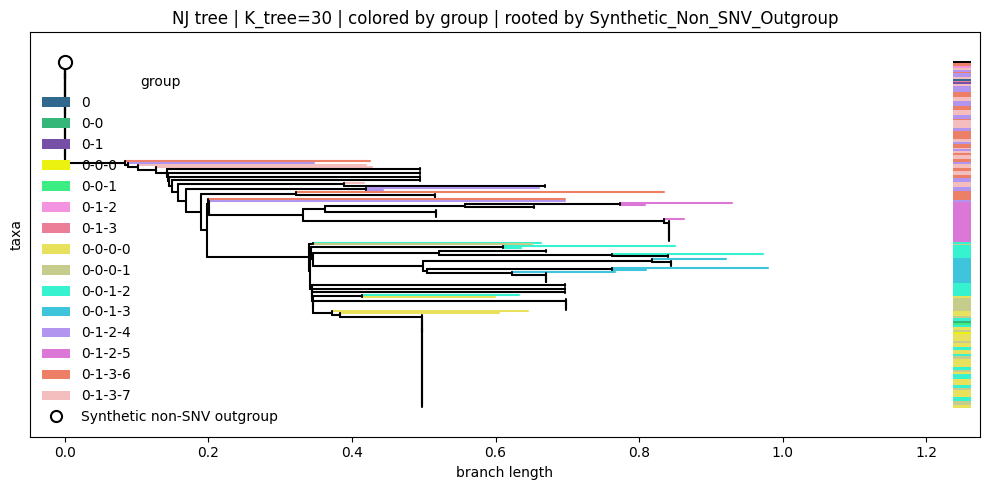

Saved NJ tree: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-09_maxcells_20.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max20_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-09_maxcells_20.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 184, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 34.983575252971804, 'target_n_parts': 4, 'p_up': '1e-09', 'max_cells': 20, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 191, 'n_snv_after_filter': 48, 'n_obs_for_tree': 191, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max20_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max20cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max20_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-09_maxce

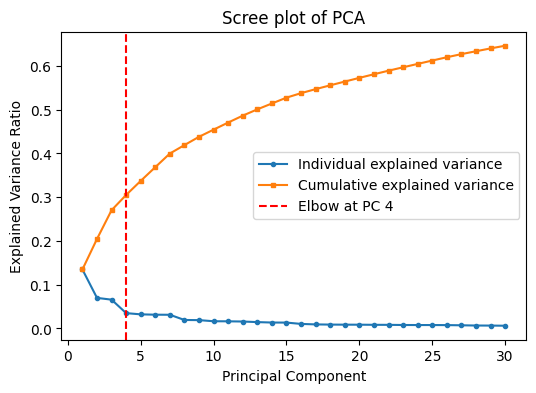

Automatically detected elbow PC number: 4
Saved elbow plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p01.PC_elbow_mutations_1e-05_maxcells_50_plot.pdf


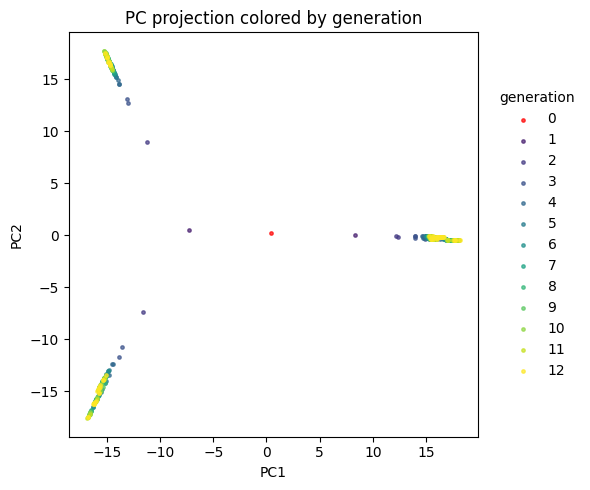

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_generation_mutations_1e-05_maxcells_50.pdf


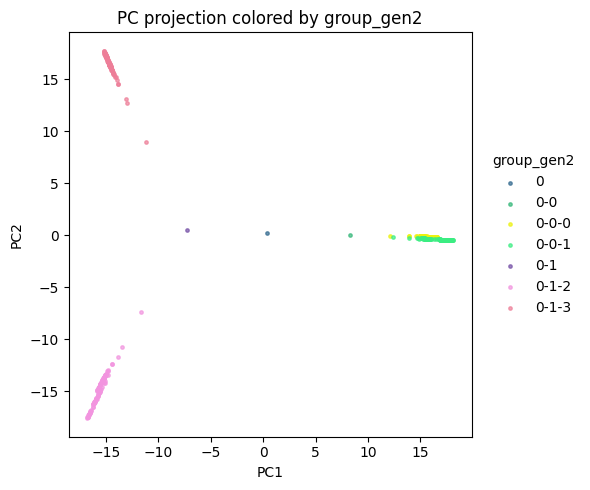

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-05_maxcells_50.pdf


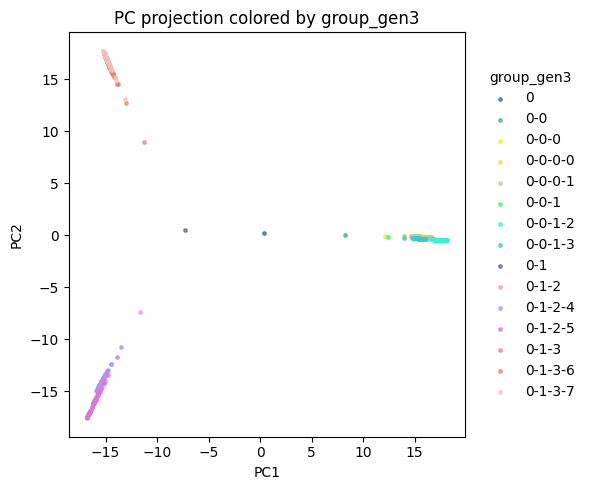

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-05_maxcells_50.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-05, max_cells = 50, n_group = 2, K mode = PC2, K_tree = 2


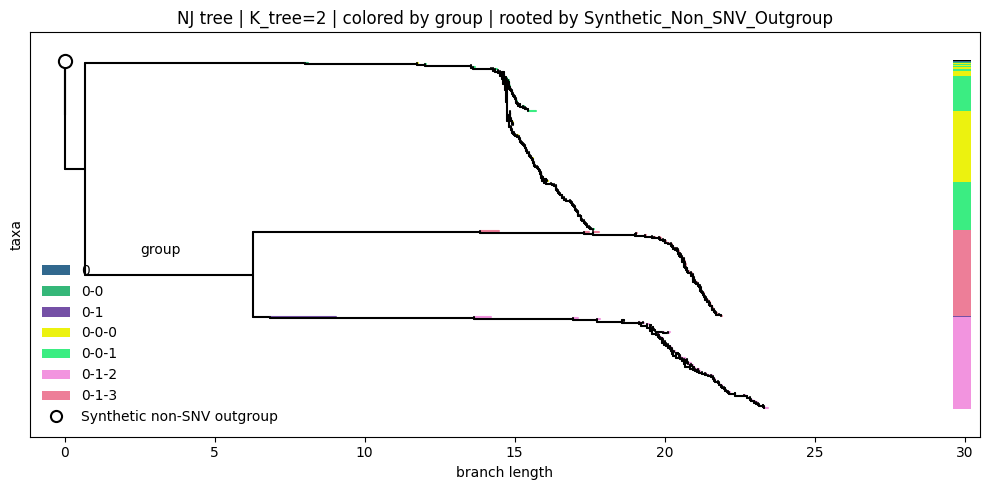

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-05_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-05_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 68.09027060524684, 'target_n_parts': 3, 'p_up': '1e-05', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 843794, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-05_maxcells_50

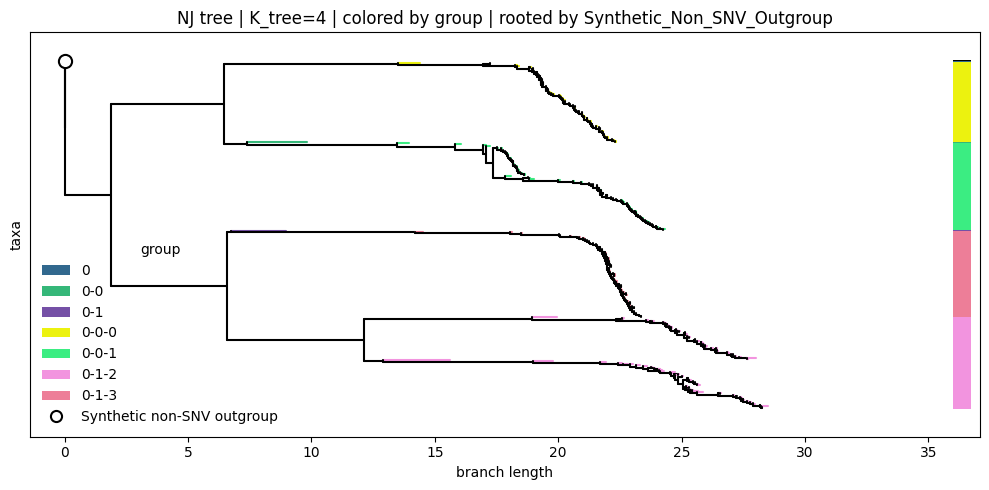

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-05_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K4_mutations_1e-05_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-05', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 843794, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-05_max

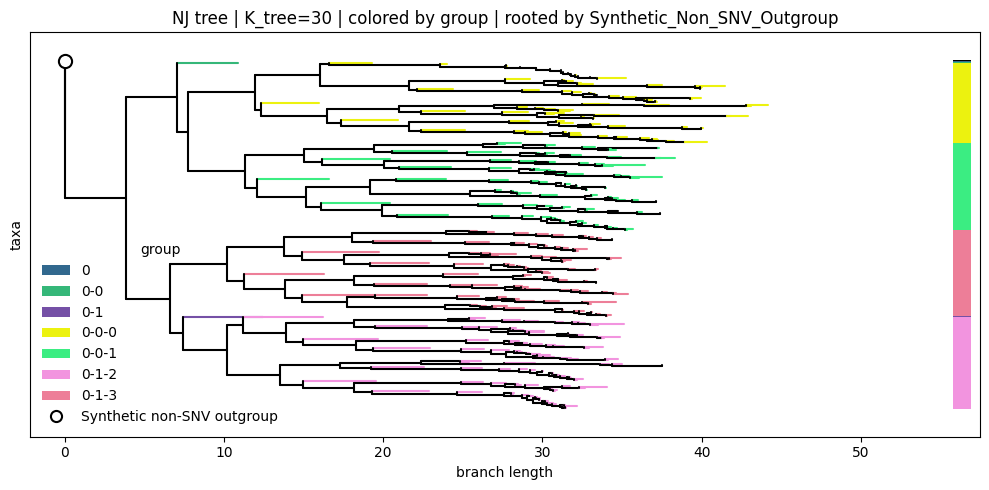

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-05_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-05_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-05', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 843794, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-05_maxcells_50.pdf

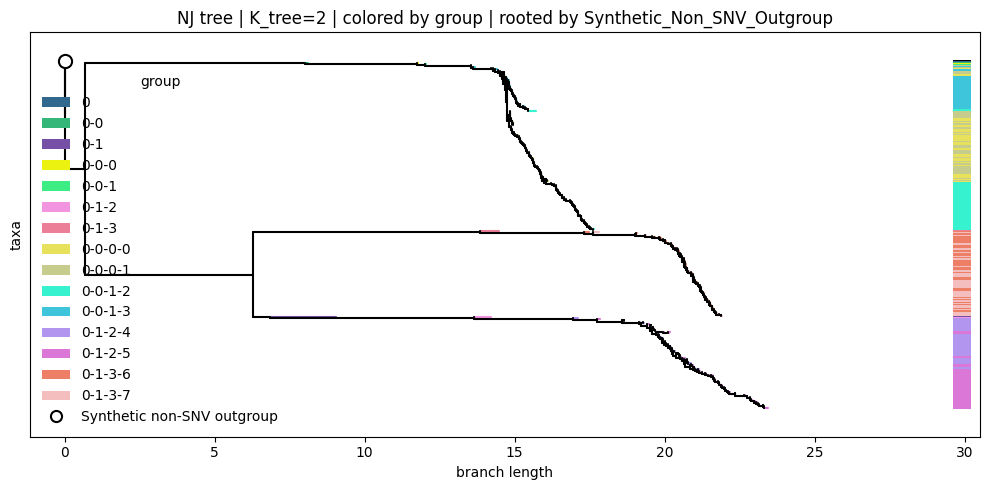

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-05_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-05_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 28.46853831670526, 'target_n_parts': 4, 'p_up': '1e-05', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 843794, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-05_maxcells_5

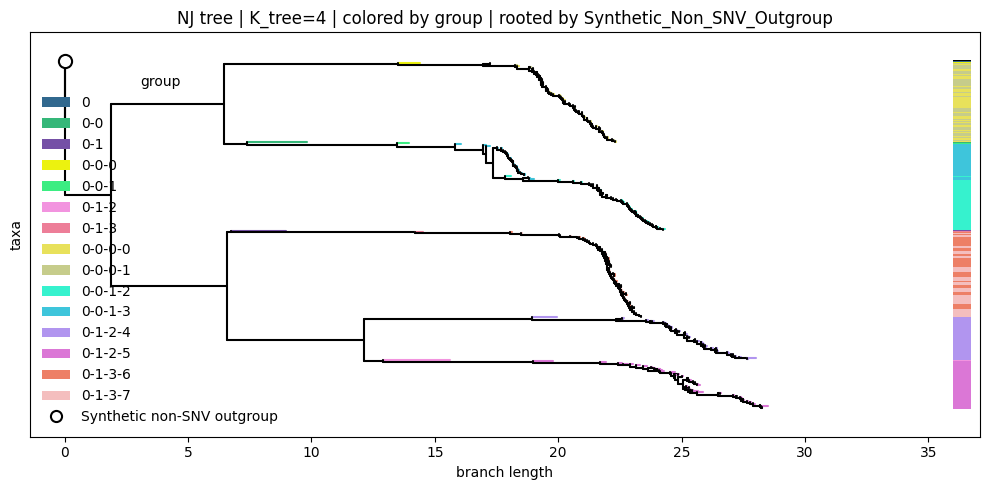

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutations_1e-05_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K4_mutations_1e-05_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 54.088975515975214, 'target_n_parts': 4, 'p_up': '1e-05', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 843794, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutat

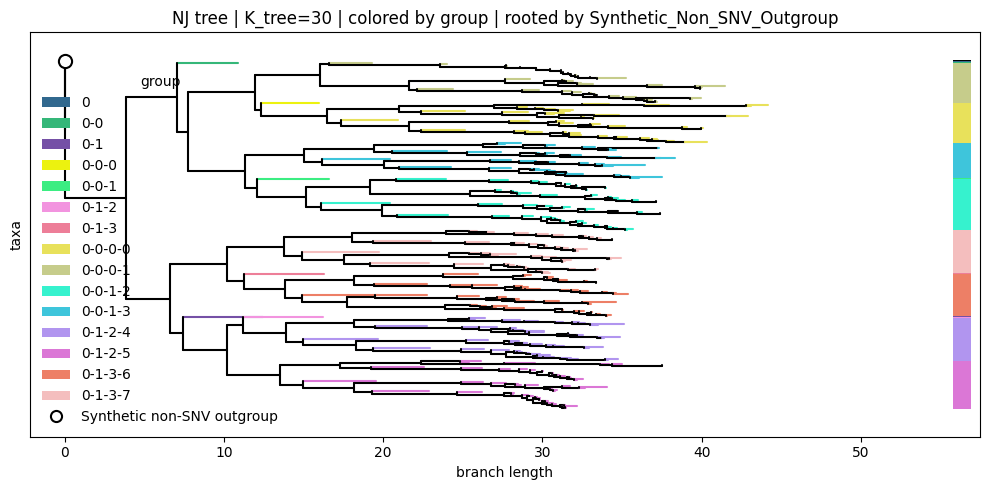

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-05_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-05_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-05', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 843794, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-05_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-05_maxcells_50.pd

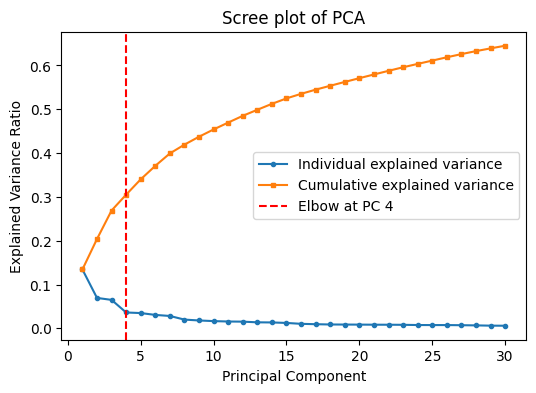

Automatically detected elbow PC number: 4
Saved elbow plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p01.PC_elbow_mutations_1e-06_maxcells_50_plot.pdf


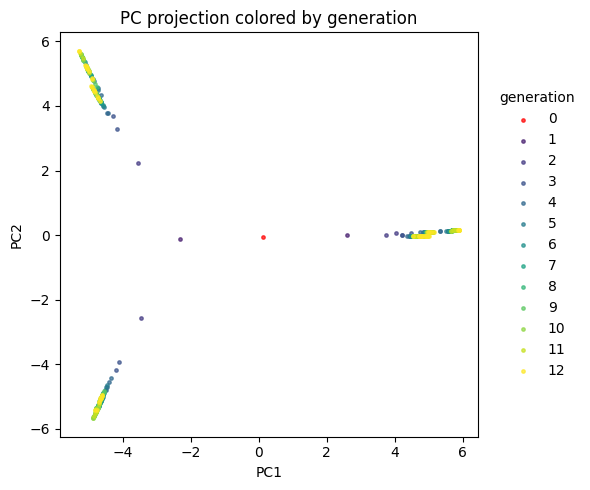

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_generation_mutations_1e-06_maxcells_50.pdf


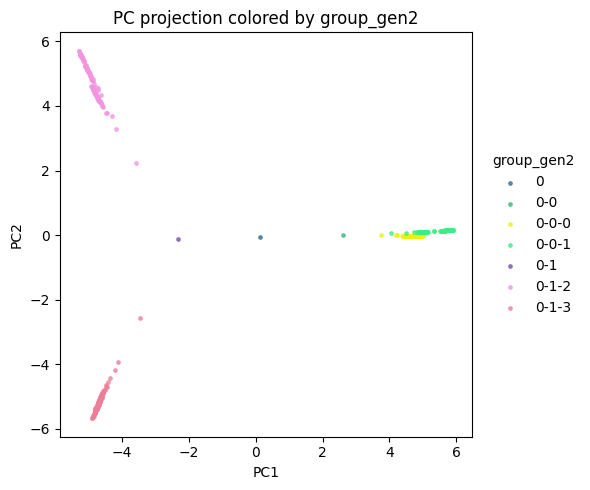

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-06_maxcells_50.pdf


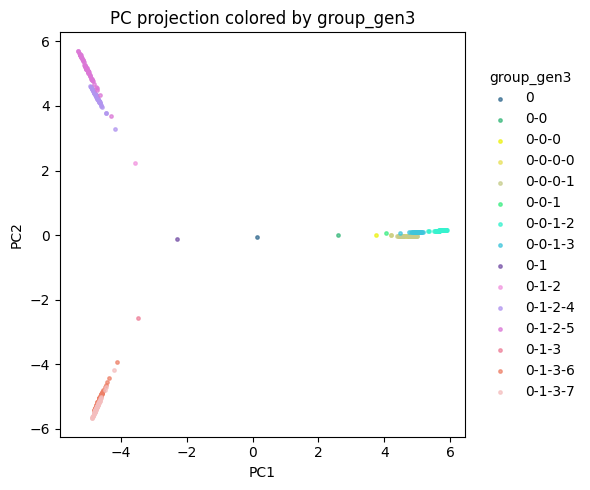

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-06_maxcells_50.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-06, max_cells = 50, n_group = 2, K mode = PC2, K_tree = 2


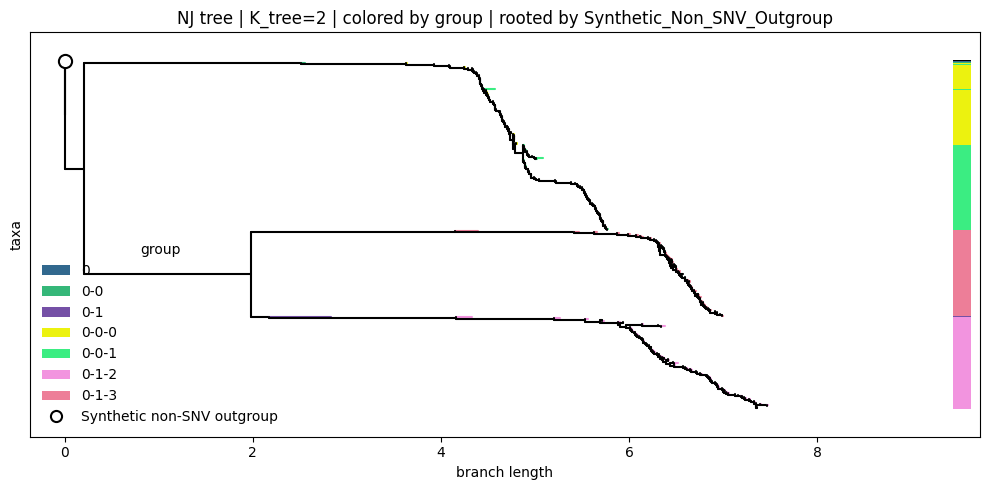

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-06_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-06_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 76.37626523445569, 'target_n_parts': 3, 'p_up': '1e-06', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 84415, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-06_maxcells_50.

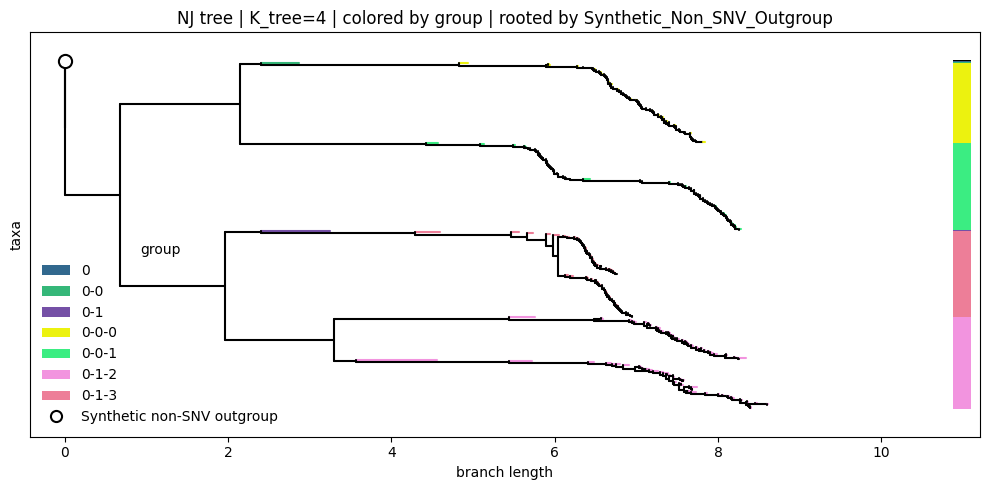

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-06_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K4_mutations_1e-06_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-06', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 84415, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K4_mutations_1e-06_maxc

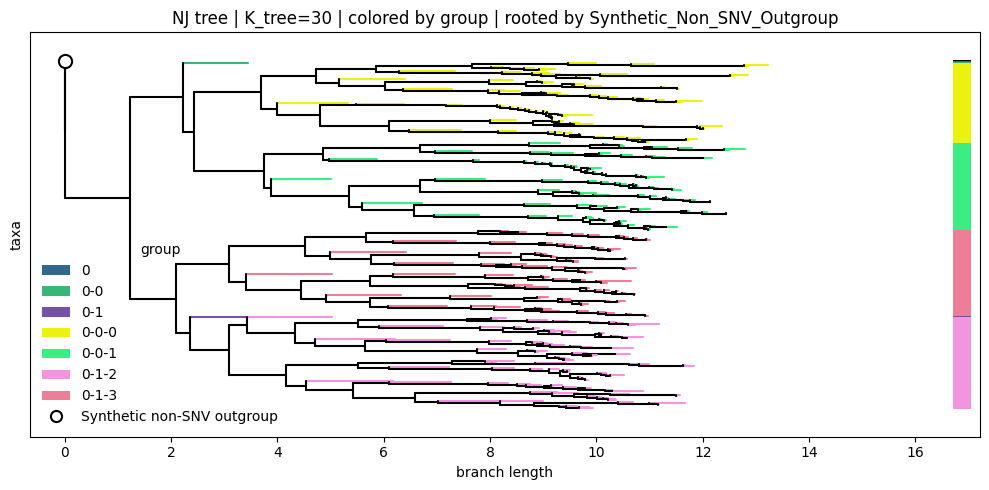

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-06_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-06_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-06', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 84415, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-06_maxcells_50.pdf'

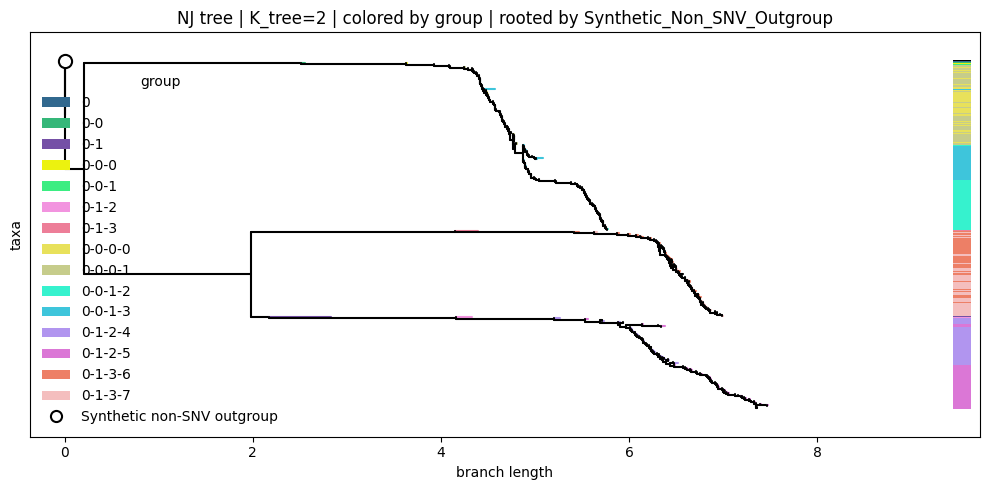

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-06_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-06_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 35.593264638835386, 'target_n_parts': 4, 'p_up': '1e-06', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 84415, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-06_maxcells_5

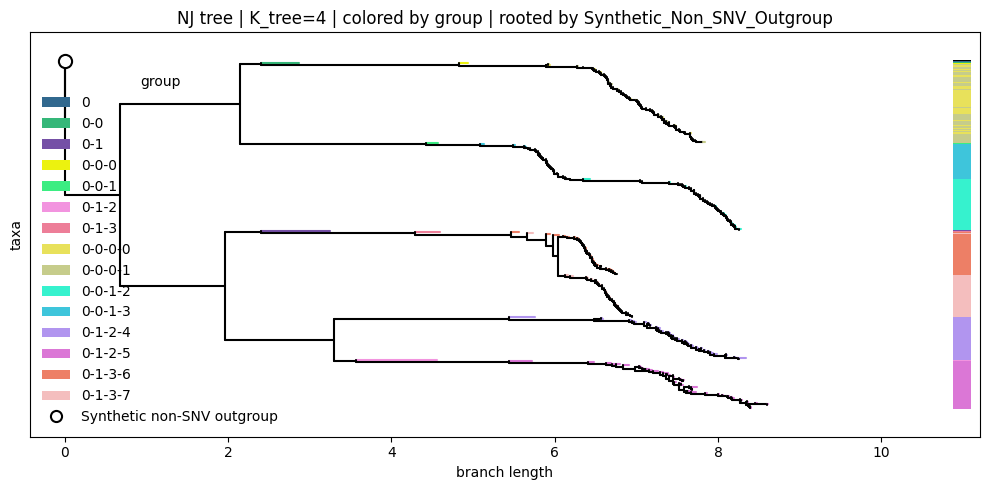

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutations_1e-06_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K4_mutations_1e-06_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 65.08358040989461, 'target_n_parts': 4, 'p_up': '1e-06', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 4, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 84415, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K4_mutatio

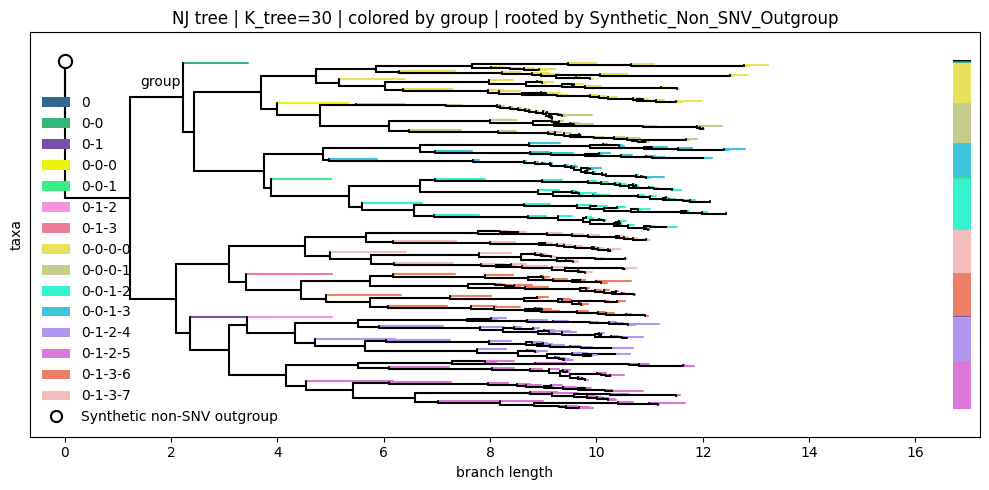

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-06_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-06_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-06', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 4, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 84415, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-06_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-06_maxcells_50.pdf

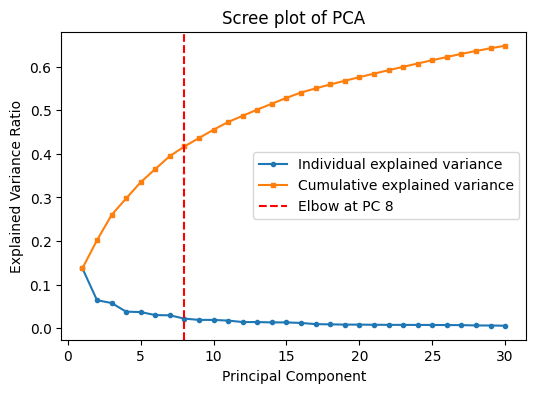

Automatically detected elbow PC number: 8
Saved elbow plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p01.PC_elbow_mutations_1e-07_maxcells_50_plot.pdf


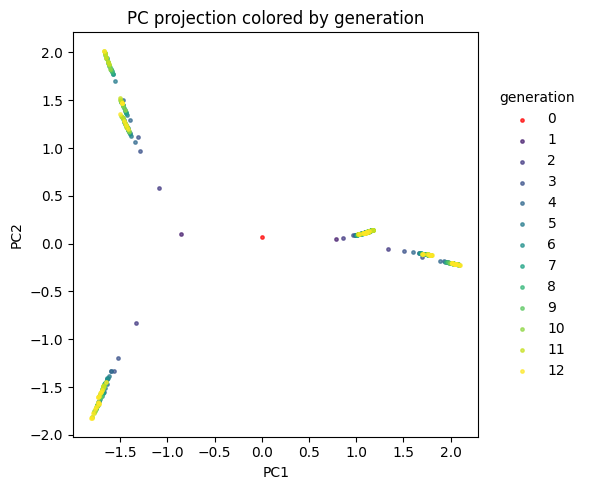

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_generation_mutations_1e-07_maxcells_50.pdf


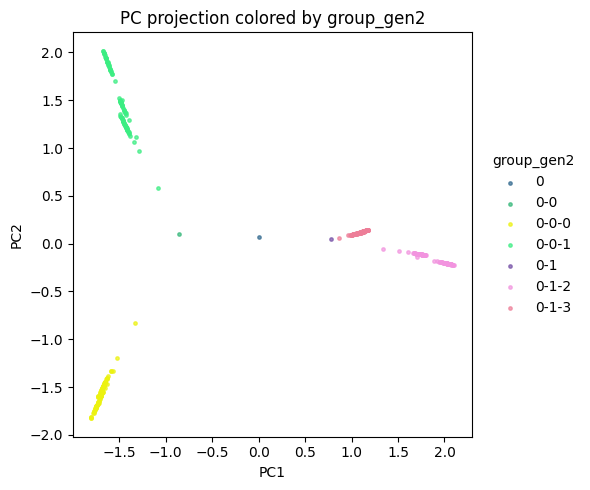

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-07_maxcells_50.pdf


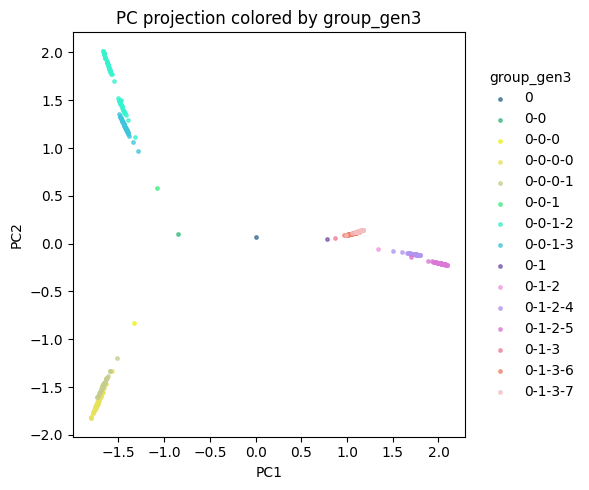

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-07_maxcells_50.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-07, max_cells = 50, n_group = 2, K mode = PC2, K_tree = 2


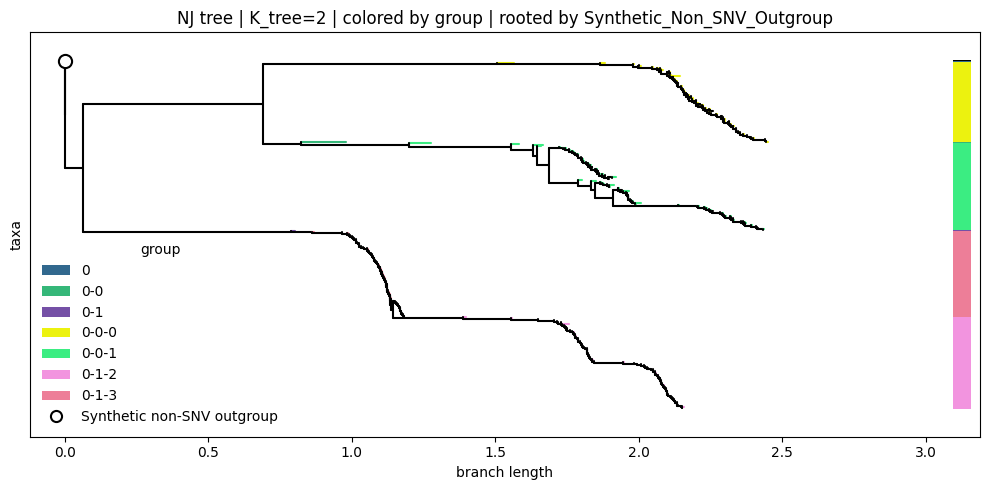

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-07_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-07_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 79.70297029702971, 'target_n_parts': 3, 'p_up': '1e-07', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 8452, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-07_maxcells_50.p

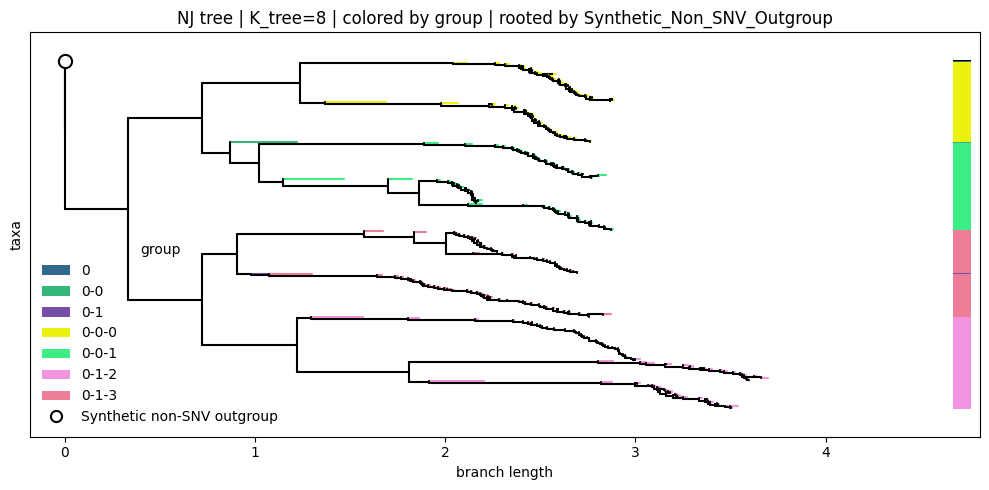

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K8_mutations_1e-07_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K8_mutations_1e-07_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-07', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 8, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 8452, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K8_mutations_1e-07_maxce

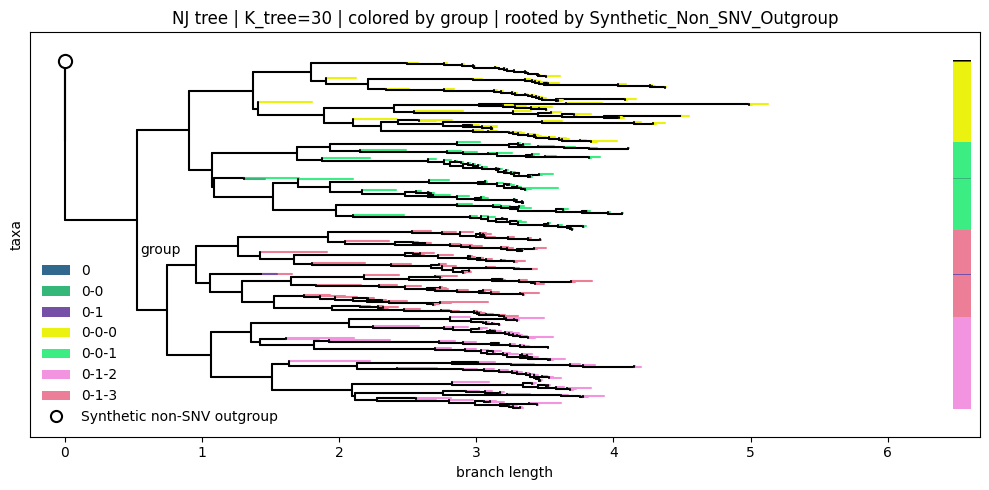

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-07_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-07_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-07', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 8452, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-07_maxcells_50.pdf',

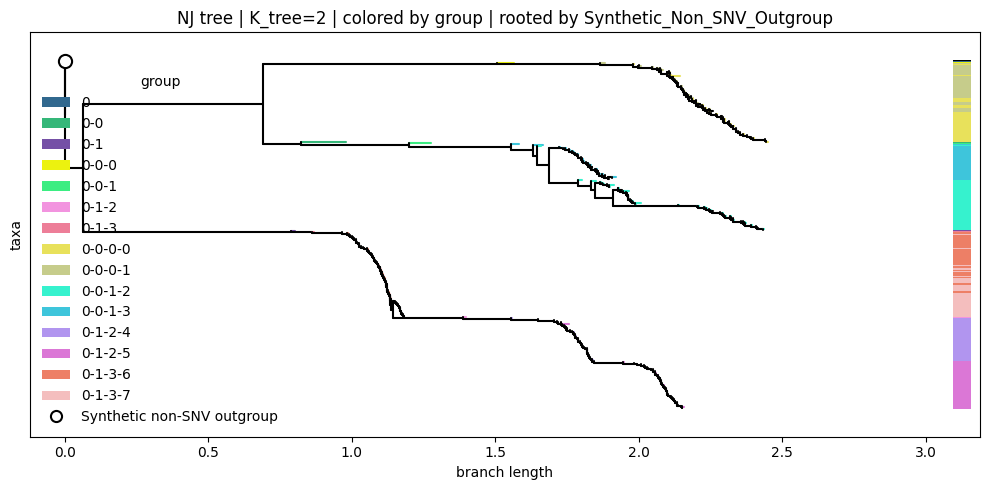

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-07_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-07_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 52.311624411164246, 'target_n_parts': 4, 'p_up': '1e-07', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 8452, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-07_maxcells_50

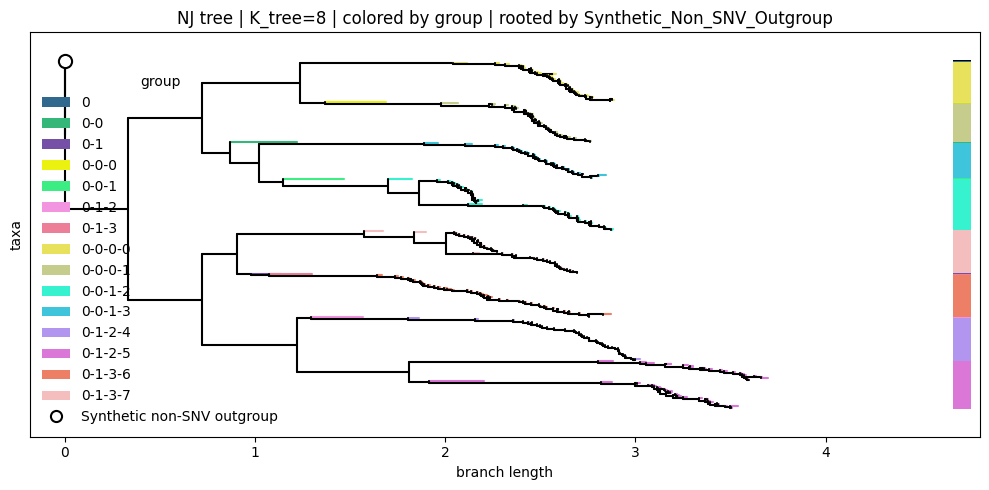

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K8_mutations_1e-07_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K8_mutations_1e-07_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-07', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 8, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 8452, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K8_mutations_1e-07_maxc

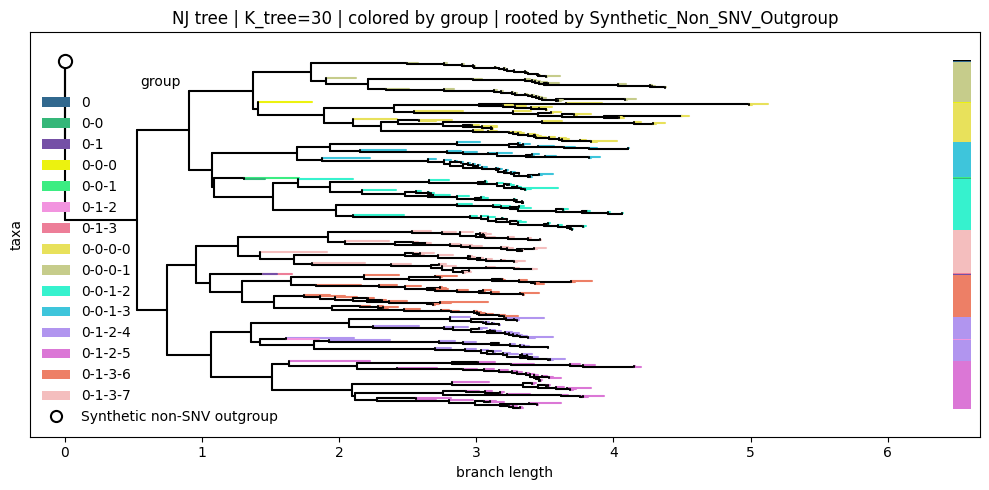

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-07_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-07_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 4, 'p_up': '1e-07', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 8, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 8452, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-07_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-07_maxcells_50.pdf'

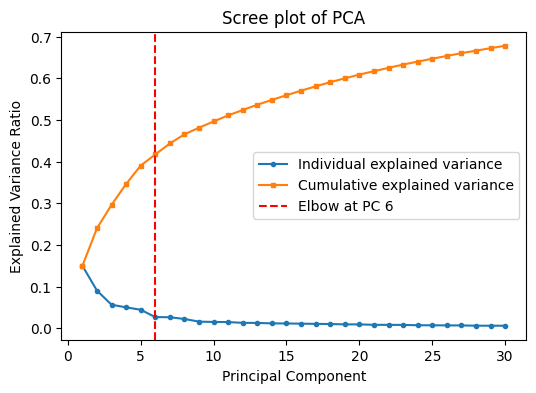

Automatically detected elbow PC number: 6
Saved elbow plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p01.PC_elbow_mutations_1e-08_maxcells_50_plot.pdf


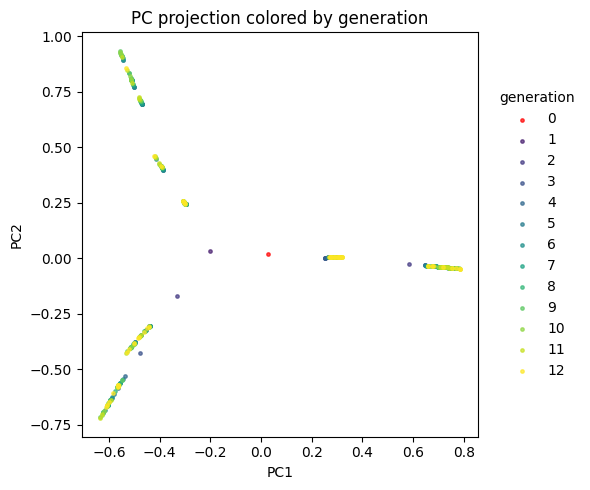

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_generation_mutations_1e-08_maxcells_50.pdf


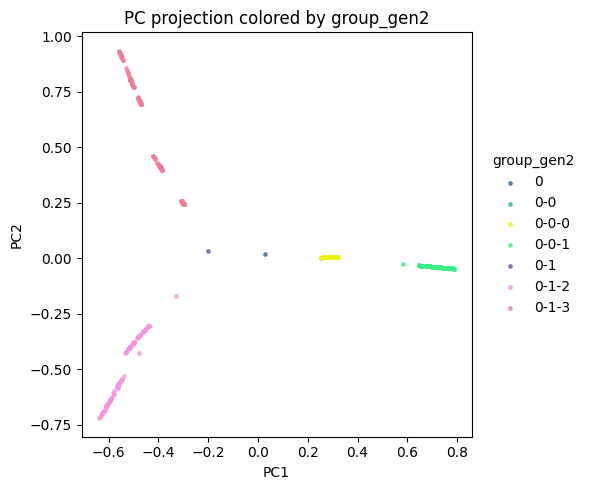

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-08_maxcells_50.pdf


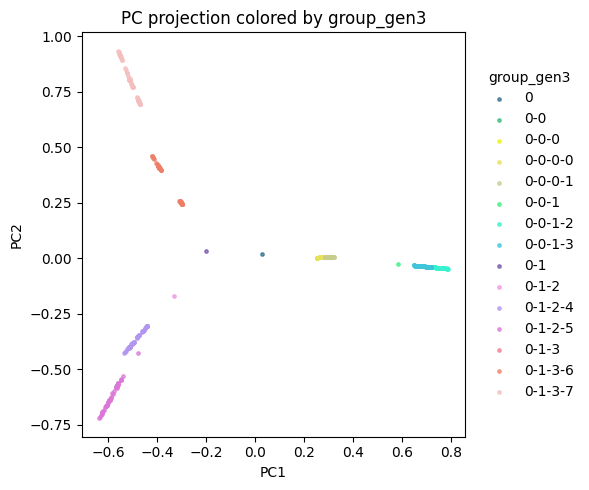

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-08_maxcells_50.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-08, max_cells = 50, n_group = 2, K mode = PC2, K_tree = 2


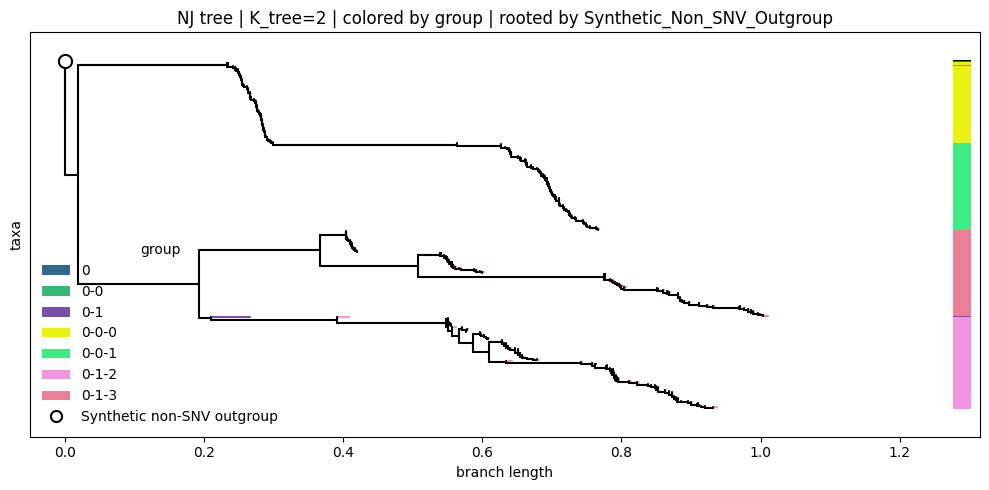

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-08_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-08_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 75.79787234042553, 'target_n_parts': 3, 'p_up': '1e-08', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 831, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-08_maxcells_50.pd

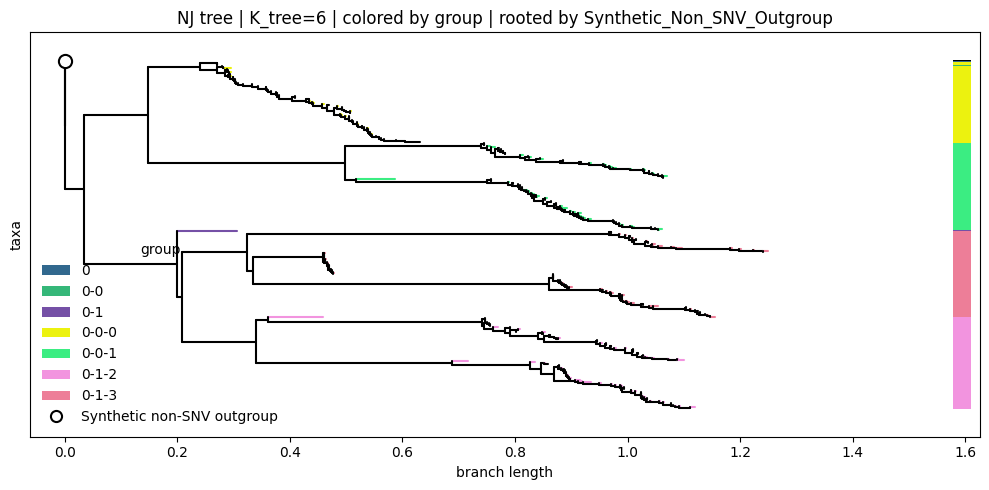

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K6_mutations_1e-08_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K6_mutations_1e-08_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 100.0, 'target_n_parts': 3, 'p_up': '1e-08', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 6, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 831, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K6_mutations_1e-08_maxcel

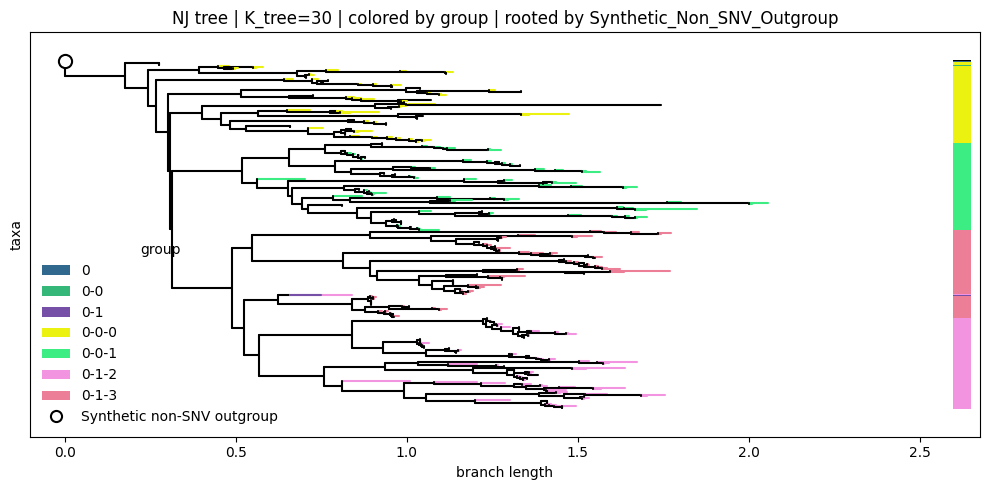

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-08_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-08_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 80.56691750735357, 'target_n_parts': 3, 'p_up': '1e-08', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 831, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-08_maxcel

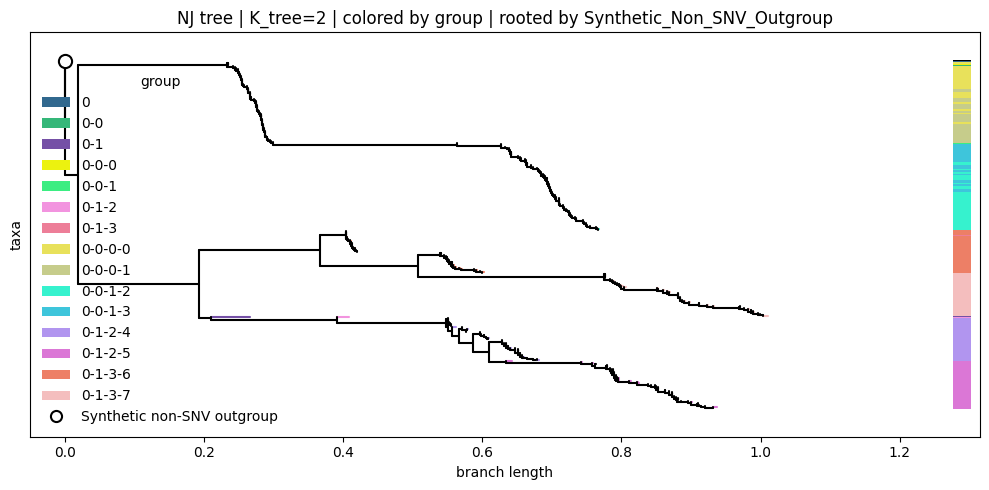

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-08_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-08_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 48.2575673959934, 'target_n_parts': 4, 'p_up': '1e-08', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 831, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-08_maxcells_50.pd

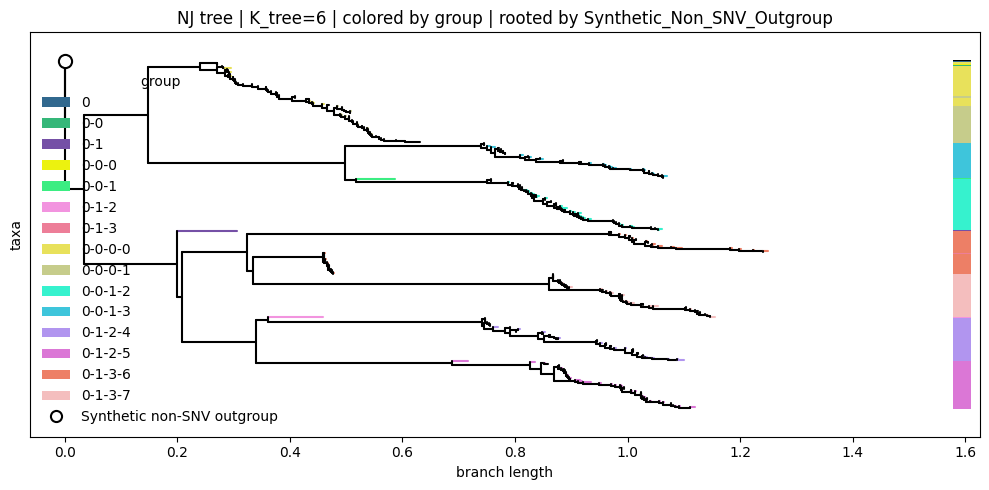

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K6_mutations_1e-08_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K6_mutations_1e-08_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 81.6659272404614, 'target_n_parts': 4, 'p_up': '1e-08', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 6, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 831, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K6_mutations_

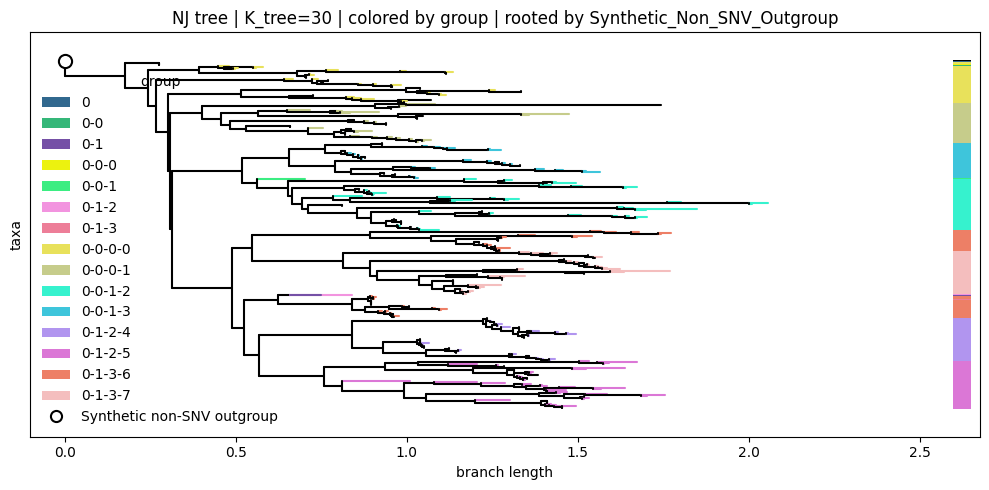

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-08_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-08_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 86.01375332741792, 'target_n_parts': 4, 'p_up': '1e-08', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 831, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-08_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-08_maxce

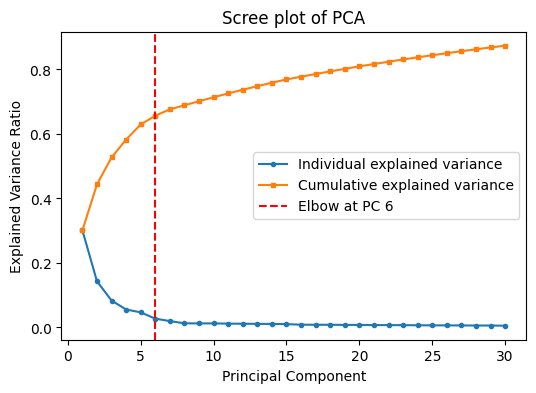

Automatically detected elbow PC number: 6
Saved elbow plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p01.PC_elbow_mutations_1e-09_maxcells_50_plot.pdf


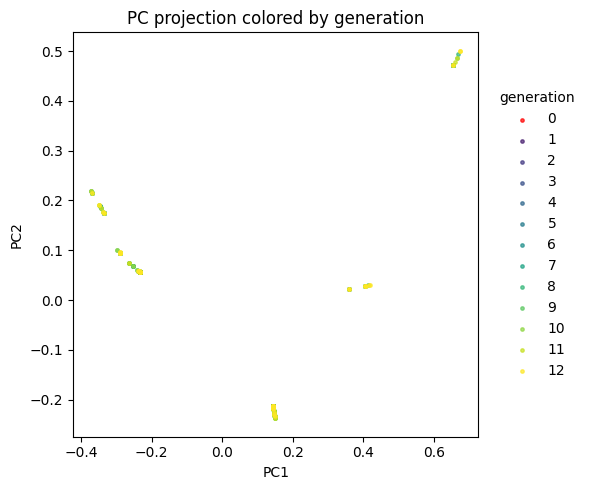

Saved PC1 vs PC2 generation plot: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_generation_mutations_1e-09_maxcells_50.pdf


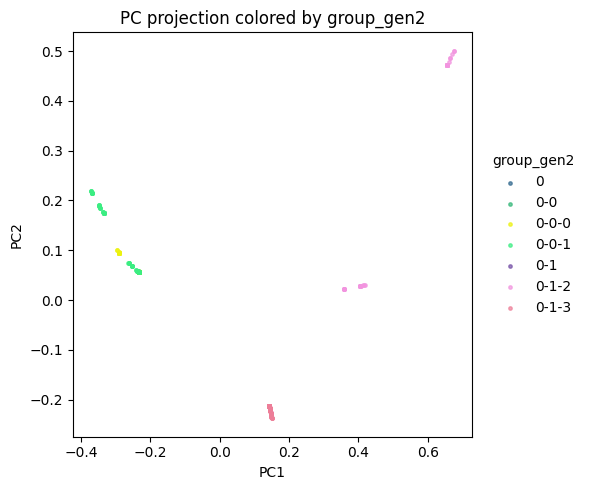

Saved PC1 vs PC2 lineage plot for n_group = 2: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group2_mutations_1e-09_maxcells_50.pdf


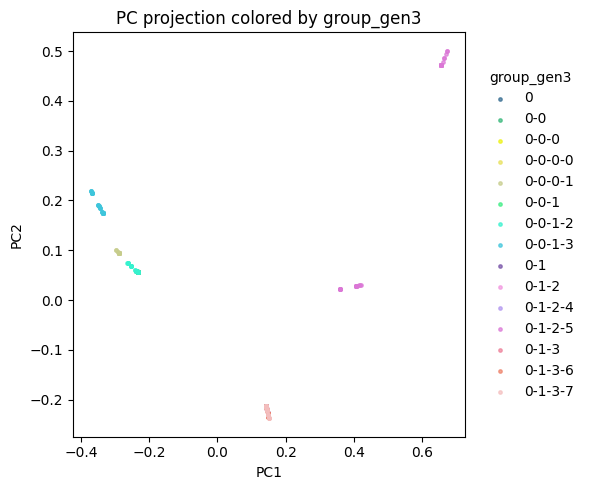

Saved PC1 vs PC2 lineage plot for n_group = 3: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p02.2dPC_lineage_n_group3_mutations_1e-09_maxcells_50.pdf
----------------------------------------------------------------------------------------------------
Building NJ tree for p_up = 1e-09, max_cells = 50, n_group = 2, K mode = PC2, K_tree = 2


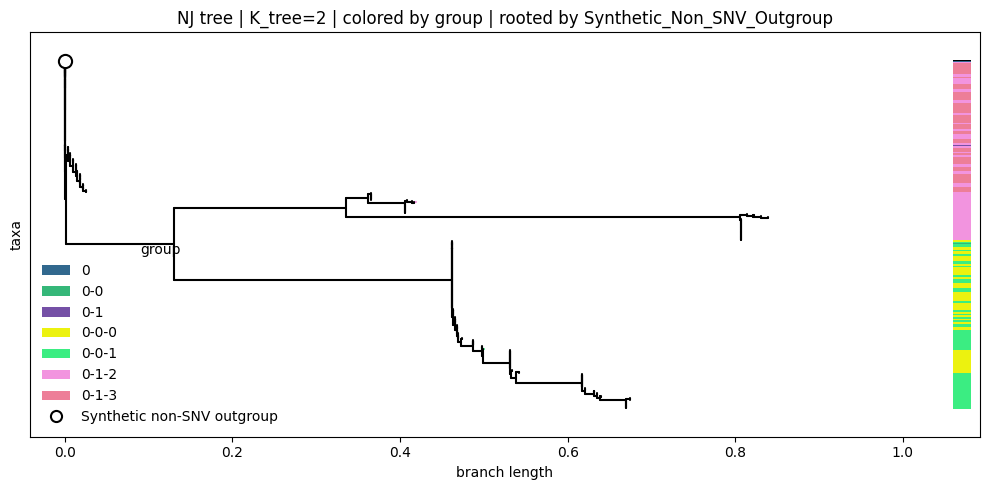

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-09_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC2_K2_mutations_1e-09_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 30.764113817565054, 'target_n_parts': 3, 'p_up': '1e-09', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 94, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC2_K2_mutations_1e-09_maxcells_50.pd

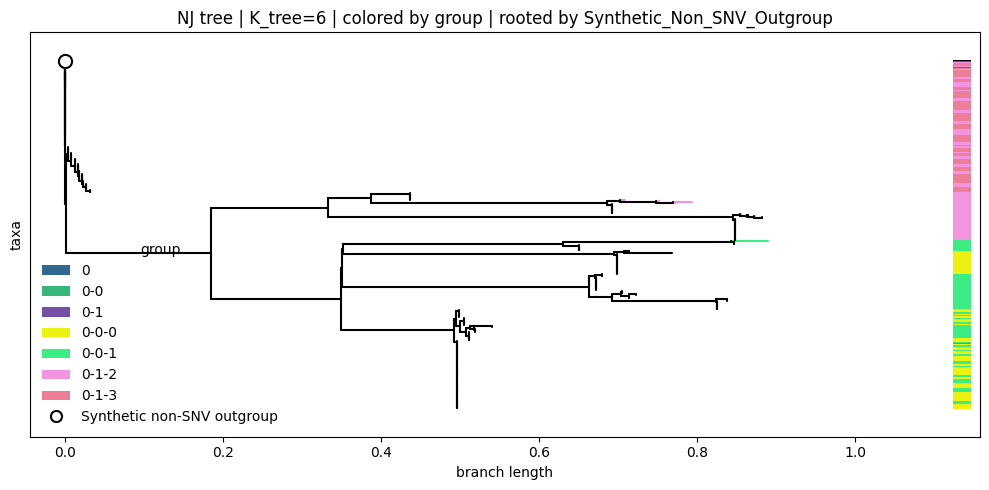

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K6_mutations_1e-09_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC_elbow_K6_mutations_1e-09_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 31.827943604799092, 'target_n_parts': 3, 'p_up': '1e-09', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC_elbow', 'K_tree': 6, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 94, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC_elbow_K6_mutations_

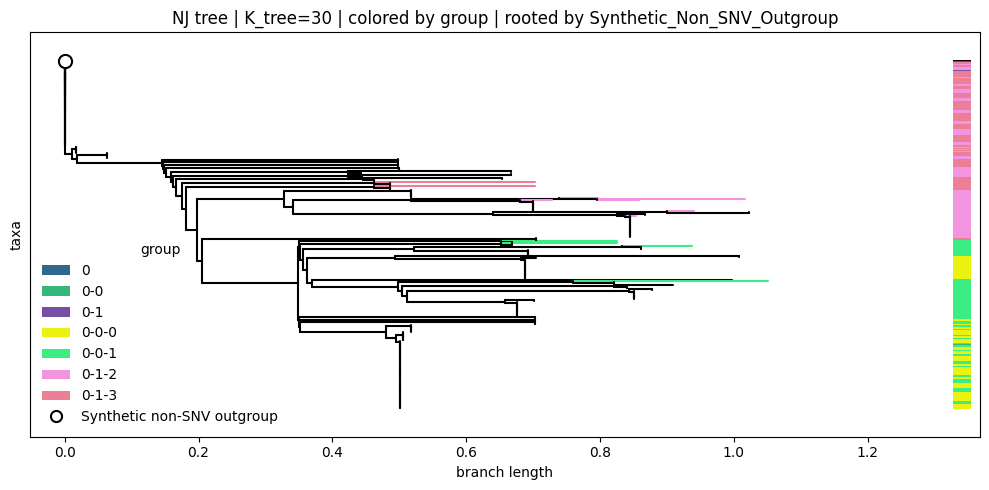

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-09_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group2_PC30_K30_mutations_1e-09_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 4, 'n_target_cells': 410, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 31.57080624057723, 'target_n_parts': 3, 'p_up': '1e-09', 'max_cells': 50, 'n_group': 2, 'group_key': 'group_gen2', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 94, 'n_obs_for_tree': 413, 'n_group_for_tree': 7, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group2_PC30_K30_mutations_1e-09_maxcell

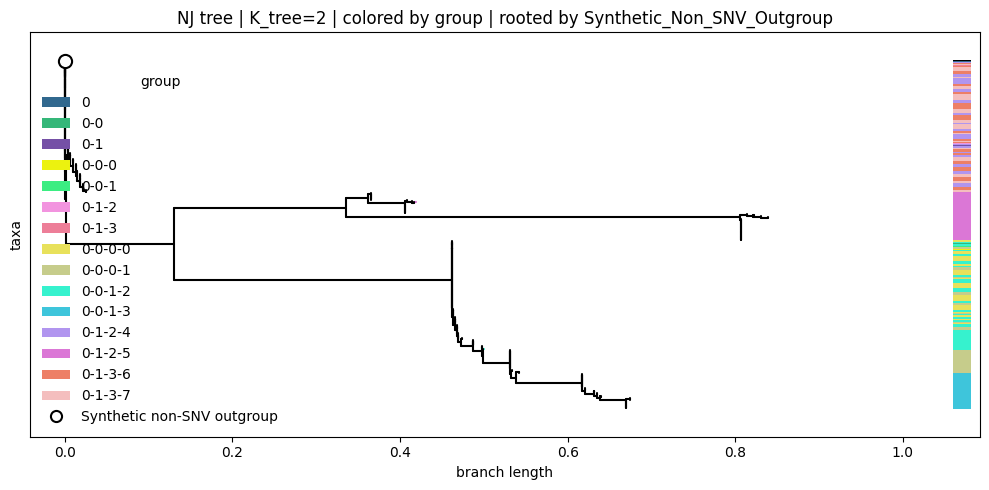

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-09_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC2_K2_mutations_1e-09_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 35.58052351375333, 'target_n_parts': 4, 'p_up': '1e-09', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC2', 'K_tree': 2, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 94, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC2_K2_mutations_1e-09_maxcells_50.pd

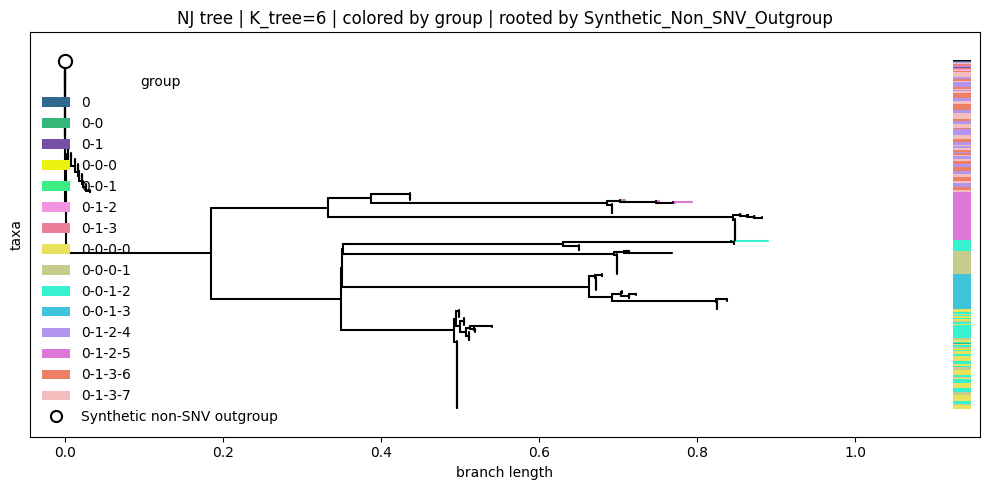

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K6_mutations_1e-09_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC_elbow_K6_mutations_1e-09_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 37.709146702159124, 'target_n_parts': 4, 'p_up': '1e-09', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC_elbow', 'K_tree': 6, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 94, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC_elbow_K6_mutations

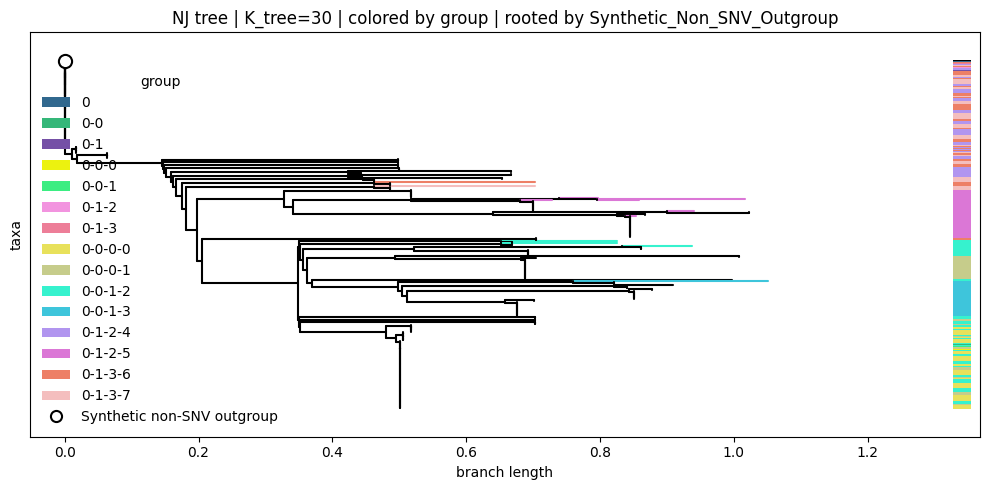

Saved NJ tree: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-09_maxcells_50.pdf
Saved topology lineage Q table: Simulation_setting1_with_GEINJ/max50_cells_per_generation/p04.Topology_lineage_Q_n_group3_PC30_K30_mutations_1e-09_maxcells_50.csv
Topology lineage Q summary:
{'n_target_groups': 8, 'n_target_cells': 406, 'n_singleton_target_groups': 0, 'topology_lineage_Q_percent': 38.21424874297546, 'target_n_parts': 4, 'p_up': '1e-09', 'max_cells': 50, 'n_group': 3, 'group_key': 'group_gen3', 'K_mode': 'PC30', 'K_tree': 30, 'elbow_PC': 6, 'n_available_pcs': 30, 'n_obs_after_filter': 413, 'n_snv_after_filter': 94, 'n_obs_for_tree': 413, 'n_group_for_tree': 15, 'input_file': './h5ad_simu_filtered/max50_cells_per_generation/diploid_12_generations_1cell_1e+08mutations_1e-09_max50cells_per_generation_nonzeroSNV.h5ad', 'tree_file': 'Simulation_setting1_with_GEINJ/max50_cells_per_generation/p03.NJ_tree_n_group3_PC30_K30_mutations_1e-09_maxcel

In [4]:
os.makedirs(outdir_root, exist_ok=True)

all_topology_q_summary = []


def find_input_file(p_up_str, max_cells_value):
    infile = infile_template.format(
        p_up=p_up_str,
        max_cells=max_cells_value,
    )

    if os.path.exists(infile):
        return infile

    pattern = (
        f"./h5ad_simu_filtered/"
        f"max{max_cells_value}_cells_per_generation/"
        f"*mutations_{p_up_str}_max{max_cells_value}cells_per_generation_nonzeroSNV.h5ad"
    )

    hits = sorted(glob(pattern))

    if len(hits) == 0:
        raise FileNotFoundError(
            f"No input file found.\n"
            f"Tried exact path:\n{infile}\n"
            f"Tried glob pattern:\n{pattern}"
        )

    if len(hits) > 1:
        print("Warning: multiple matched files were found. Use the first one:")
        for hit in hits:
            print("  ", hit)

    return hits[0]


for max_cells_value in max_cells:
    outdir = os.path.join(
        outdir_root,
        f"max{max_cells_value}_cells_per_generation"
    )
    os.makedirs(outdir, exist_ok=True)

    print("\n" + "#" * 100)
    print(f"Start analyses for max_cells = {max_cells_value}")
    print(f"Output folder: {outdir}")

    for mu in p_ups:
        p_up_str = fmt_p_up(mu)

        infile = find_input_file(
            p_up_str=p_up_str,
            max_cells_value=max_cells_value,
        )

        print("\n" + "=" * 100)
        print(f"Processing p_up = {p_up_str}")
        print(f"Processing max_cells = {max_cells_value}")
        print(f"Input file: {infile}")

        adata = ad.read_h5ad(infile)
        adata.obs_names_make_unique()

        print("adata.shape:", adata.shape)

        # No additional cell filtering is performed here.
        # Cells were already quality controlled in the previous script.

        # Build lineage grouping columns for n_group = 2 and n_group = 3.
        # Here n_group means the number of '-' levels.
        # n_group = 2 gives labels such as 0-0-0.
        # n_group = 3 gives labels such as 0-0-0-0.
        for n_group in n_groups:
            group_key = f"group_gen{n_group}"
            adata.obs.loc[:, group_key] = (
                adata.obs["lineage"]
                .astype("string")
                .str.split("-")
                .str[: (n_group + 1)]
                .str.join("-")
            )

        # PCA is calculated once for each p_up and max_cells setting.
        max_n_comps = min(adata.n_obs - 1, adata.n_vars - 1, 30)

        if max_n_comps < 2:
            raise ValueError(
                f"Too few observations or SNVs for PCA: adata.shape = {adata.shape}"
            )

        sc.pp.pca(adata, n_comps=max_n_comps, random_state=42)

        explained_var = adata.uns["pca"]["variance_ratio"]
        explained_var_cum = explained_var.cumsum()
        n_available_pcs = adata.obsm["X_pca"].shape[1]

        print("Number of available PCs:", n_available_pcs)

        kl = KneeLocator(
            range(1, len(explained_var) + 1),
            explained_var,
            curve="convex",
            direction="decreasing",
        )

        elbow_PC = kl.elbow

        if elbow_PC is None:
            elbow_PC = (
                int(np.argmax(explained_var_cum >= 0.8) + 1)
                if np.any(explained_var_cum >= 0.8)
                else 10
            )
            elbow_PC = min(elbow_PC, n_available_pcs)
            print(f"Elbow PC was not detected. Use fallback K = {elbow_PC}")
        else:
            elbow_PC = int(elbow_PC)
            elbow_PC = min(elbow_PC, n_available_pcs)

        pc2_K = min(2, n_available_pcs)
        pc30_K = min(30, n_available_pcs)

        k_settings = [
            ("PC2", pc2_K),
            ("PC_elbow", elbow_PC),
            ("PC30", pc30_K),
        ]

        # Save PCA elbow plot.
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(
            range(1, len(explained_var) + 1),
            explained_var,
            "o-",
            markersize=3,
            label="Individual explained variance",
        )

        ax.plot(
            range(1, len(explained_var) + 1),
            explained_var_cum,
            "s-",
            markersize=3,
            label="Cumulative explained variance",
        )

        ax.axvline(
            elbow_PC,
            color="r",
            linestyle="--",
            label=f"Elbow at PC {elbow_PC}",
        )

        ax.set_xlabel("Principal Component")
        ax.set_ylabel("Explained Variance Ratio")
        ax.legend()
        ax.set_title("Scree plot of PCA")

        elbow_out = os.path.join(
            outdir,
            f"p01.PC_elbow_mutations_{p_up_str}_maxcells_{max_cells_value}_plot.pdf",
        )

        fig.savefig(elbow_out, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Automatically detected elbow PC number:", elbow_PC)
        print("Saved elbow plot:", elbow_out)

        # Save 2D PC plot colored by generation.
        adata.obs["generation"] = adata.obs["generation"].astype(int).astype("category")

        pc2d_generation_out = os.path.join(
            outdir,
            f"p02.2dPC_generation_mutations_{p_up_str}_maxcells_{max_cells_value}.pdf",
        )

        plot_snv_pca_by_group(
            adata,
            pcx=1,
            pcy=2,
            group_by="generation",
            group_colors=gen_colors,
            savepath=pc2d_generation_out,
        )

        print("Saved PC1 vs PC2 generation plot:", pc2d_generation_out)

        # Save 2D PC plots colored by lineage group under n_group = 2 and 3.
        for n_group in n_groups:
            group_key = f"group_gen{n_group}"
            group_colors = group_colors_by_ngroup[n_group]

            pc2d_lineage_out = os.path.join(
                outdir,
                f"p02.2dPC_lineage_n_group{n_group}_mutations_{p_up_str}_maxcells_{max_cells_value}.pdf",
            )

            plot_snv_pca_by_group(
                adata,
                pcx=1,
                pcy=2,
                group_by=group_key,
                group_colors=group_colors,
                savepath=pc2d_lineage_out,
            )

            print(
                f"Saved PC1 vs PC2 lineage plot for n_group = {n_group}:",
                pc2d_lineage_out,
            )

        # Build NJ trees and calculate topology lineage Q.
        # No additional cell subsetting is performed.
        for n_group in n_groups:
            group_key = f"group_gen{n_group}"
            group_colors = group_colors_by_ngroup[n_group]

            # build_and_plot_nj uses group_key="group" in many GEI-NJ examples.
            # Here we copy the selected lineage level into "group" for plotting and Q evaluation.
            adata.obs.loc[:, "group"] = adata.obs[group_key].astype(str)

            for k_mode, k_tree in k_settings:
                print("-" * 100)
                print(
                    f"Building NJ tree for p_up = {p_up_str}, "
                    f"max_cells = {max_cells_value}, "
                    f"n_group = {n_group}, "
                    f"K mode = {k_mode}, "
                    f"K_tree = {k_tree}"
                )

                tree_out = os.path.join(
                    outdir,
                    f"p03.NJ_tree_n_group{n_group}_{k_mode}_K{k_tree}_"
                    f"mutations_{p_up_str}_maxcells_{max_cells_value}.pdf",
                )

                tree_return = build_and_plot_nj(
                    adata,
                    figsize=(10, 5),
                    group_colors=group_colors,
                    K_tree=k_tree,
                    leafcolor_onside=True,
                    group_key="group",
                    show_legend=True,
                    savepath=tree_out,
                    return_tree_info=True,
                )

                print("Saved NJ tree:", tree_out)

                topology_q_df, topology_q_summary = evaluate_topology_lineage_Q(
                    tree_return,
                    adata,
                    group_key="group",
                    target_n_parts=n_group + 1,
                )

                topology_q_out = os.path.join(
                    outdir,
                    f"p04.Topology_lineage_Q_n_group{n_group}_{k_mode}_K{k_tree}_"
                    f"mutations_{p_up_str}_maxcells_{max_cells_value}.csv",
                )

                topology_q_df.to_csv(topology_q_out, index=False)

                topology_q_summary["p_up"] = p_up_str
                topology_q_summary["max_cells"] = max_cells_value
                topology_q_summary["n_group"] = n_group
                topology_q_summary["group_key"] = group_key
                topology_q_summary["K_mode"] = k_mode
                topology_q_summary["K_tree"] = k_tree
                topology_q_summary["elbow_PC"] = elbow_PC
                topology_q_summary["n_available_pcs"] = n_available_pcs
                topology_q_summary["n_obs_after_filter"] = adata.n_obs
                topology_q_summary["n_snv_after_filter"] = adata.n_vars
                topology_q_summary["n_obs_for_tree"] = adata.n_obs
                topology_q_summary["n_group_for_tree"] = adata.obs["group"].nunique()
                topology_q_summary["input_file"] = infile
                topology_q_summary["tree_file"] = tree_out
                topology_q_summary["q_table_file"] = topology_q_out

                all_topology_q_summary.append(topology_q_summary)

                print("Saved topology lineage Q table:", topology_q_out)
                print("Topology lineage Q summary:")
                print(topology_q_summary)

    # Save one summary table for each max_cells folder.
    summary_df_max = pd.DataFrame(
        [
            row for row in all_topology_q_summary
            if row.get("max_cells") == max_cells_value
        ]
    )

    summary_cols = [
        "max_cells",
        "p_up",
        "n_group",
        "group_key",
        "K_mode",
        "K_tree",
        "elbow_PC",
        "n_available_pcs",
        "n_obs_after_filter",
        "n_snv_after_filter",
        "n_obs_for_tree",
        "n_group_for_tree",
        "n_target_groups",
        "n_target_cells",
        "n_singleton_target_groups",
        "target_n_parts",
        "topology_lineage_Q_percent",
        "input_file",
        "tree_file",
        "q_table_file",
    ]

    summary_df_max = summary_df_max[
        [col for col in summary_cols if col in summary_df_max.columns]
    ]

    summary_out_max = os.path.join(
        outdir,
        f"p04.Topology_lineage_Q_summary_maxcells_{max_cells_value}.csv",
    )

    summary_df_max.to_csv(summary_out_max, index=False)

    print("\nSaved topology lineage Q summary for max_cells =", max_cells_value)
    print(summary_out_max)
    print(summary_df_max)


# Save one combined summary table across max_cells = 20 and 50.
summary_df_all = pd.DataFrame(all_topology_q_summary)

summary_cols = [
    "max_cells",
    "p_up",
    "n_group",
    "group_key",
    "K_mode",
    "K_tree",
    "elbow_PC",
    "n_available_pcs",
    "n_obs_after_filter",
    "n_snv_after_filter",
    "n_obs_for_tree",
    "n_group_for_tree",
    "n_target_groups",
    "n_target_cells",
    "n_singleton_target_groups",
    "target_n_parts",
    "topology_lineage_Q_percent",
    "input_file",
    "tree_file",
    "q_table_file",
]

summary_df_all = summary_df_all[
    [col for col in summary_cols if col in summary_df_all.columns]
]

summary_out_all = os.path.join(
    outdir_root,
    "p04.Topology_lineage_Q_summary_all_maxcells.csv",
)

summary_df_all.to_csv(summary_out_all, index=False)

print("\nSaved combined topology lineage Q summary:")
print(summary_out_all)
print(summary_df_all)